In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("1)dailyActivity_merged.csv")

In [3]:
df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 940
Columns: 15


In [5]:
df.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='str')

In [6]:
df.dtypes

Id                            int64
ActivityDate                    str
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object

In [7]:
df["ActivityDate"] = pd.to_datetime(df["ActivityDate"])

In [8]:
df.dtypes

Id                                   int64
ActivityDate                datetime64[us]
TotalSteps                           int64
TotalDistance                      float64
TrackerDistance                    float64
LoggedActivitiesDistance           float64
VeryActiveDistance                 float64
ModeratelyActiveDistance           float64
LightActiveDistance                float64
SedentaryActiveDistance            float64
VeryActiveMinutes                    int64
FairlyActiveMinutes                  int64
LightlyActiveMinutes                 int64
SedentaryMinutes                     int64
Calories                             int64
dtype: object

In [9]:
df.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

In [10]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [11]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [12]:
duplicate_user_date = df.duplicated(
    subset=["Id", "ActivityDate"]
).sum()

print("Duplicate User-Date records:", duplicate_user_date)

Duplicate User-Date records: 0


In [13]:
print("Unique users:", df["Id"].nunique())

Unique users: 33


In [14]:
df["Id"].value_counts().describe()

count    33.000000
mean     28.484848
std       5.657524
min       4.000000
25%      29.000000
50%      31.000000
75%      31.000000
max      31.000000
Name: count, dtype: float64

In [15]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Id,940.0,4855407369.332978,1503960366.0,2320127002.0,4445114986.0,6962181067.0,8877689391.0,2424805475.65796
ActivityDate,940,2016-04-26 06:53:37.021276,2016-04-12 00:00:00,2016-04-19 00:00:00,2016-04-26 00:00:00,2016-05-04 00:00:00,2016-05-12 00:00:00,NaN
TotalSteps,940.0,7637.910638,0.0,3789.75,7405.5,10727.0,36019.0,5087.150742
TotalDistance,940.0,5.489702,0.0,2.62,5.245,7.7125,28.030001,3.924606
TrackerDistance,940.0,5.475351,0.0,2.62,5.245,7.71,28.030001,3.907276
LoggedActivitiesDistance,940.0,0.108171,0.0,0.0,0.0,0.0,4.942142,0.619897
VeryActiveDistance,940.0,1.502681,0.0,0.0,0.21,2.0525,21.92,2.658941
ModeratelyActiveDistance,940.0,0.567543,0.0,0.0,0.24,0.8,6.48,0.88358
LightActiveDistance,940.0,3.340819,0.0,1.945,3.365,4.7825,10.71,2.040655
SedentaryActiveDistance,940.0,0.001606,0.0,0.0,0.0,0.0,0.11,0.007346


In [16]:
numeric_columns = df.select_dtypes(include=np.number).columns

(df[numeric_columns] < 0).sum()

Id                          0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

In [17]:
print("Start date:", df["ActivityDate"].min().date())
print("End date:", df["ActivityDate"].max().date())

Start date: 2016-04-12
End date: 2016-05-12


In [18]:
df["ActivityDate"].nunique()

31

In [21]:
df["Date"] = df["ActivityDate"]

df["Year"] = df["ActivityDate"].dt.year
df["Month"] = df["ActivityDate"].dt.month
df["MonthName"] = df["ActivityDate"].dt.month_name()
df["Day"] = df["ActivityDate"].dt.day
df["DayName"] = df["ActivityDate"].dt.day_name()

In [22]:
df["DayType"] = np.where(
    df["ActivityDate"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)

In [23]:
df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,LightlyActiveMinutes,SedentaryMinutes,Calories,Date,Year,Month,MonthName,Day,DayName,DayType
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,...,328,728,1985,2016-04-12,2016,4,April,12,Tuesday,Weekday
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,217,776,1797,2016-04-13,2016,4,April,13,Wednesday,Weekday
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,...,181,1218,1776,2016-04-14,2016,4,April,14,Thursday,Weekday
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,...,209,726,1745,2016-04-15,2016,4,April,15,Friday,Weekday
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,...,221,773,1863,2016-04-16,2016,4,April,16,Saturday,Weekend


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[us]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes      940 non

In [25]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 940
Columns: 22
Missing values: 0
Duplicate rows: 0


In [28]:
df.to_csv("dailyActivity_clean.csv", index=False)

In [29]:
df["Id"] = df["Id"].astype(str)

In [32]:
df.dtypes

Id                                     str
ActivityDate                datetime64[us]
TotalSteps                           int64
TotalDistance                      float64
TrackerDistance                    float64
LoggedActivitiesDistance           float64
VeryActiveDistance                 float64
ModeratelyActiveDistance           float64
LightActiveDistance                float64
SedentaryActiveDistance            float64
VeryActiveMinutes                    int64
FairlyActiveMinutes                  int64
LightlyActiveMinutes                 int64
SedentaryMinutes                     int64
Calories                             int64
Date                        datetime64[us]
Year                                 int32
Month                                int32
MonthName                              str
Day                                  int32
DayName                                str
DayType                                str
dtype: object

In [33]:
numeric_columns = df.select_dtypes(include=np.number).columns

(df[numeric_columns] < 0).sum()

TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
Year                        0
Month                       0
Day                         0
dtype: int64

In [34]:
minute_columns = [
    "VeryActiveMinutes",
    "FairlyActiveMinutes",
    "LightlyActiveMinutes",
    "SedentaryMinutes"
]

df["TotalRecordedMinutes"] = df[minute_columns].sum(axis=1)

print("Minimum recorded minutes:", df["TotalRecordedMinutes"].min())
print("Maximum recorded minutes:", df["TotalRecordedMinutes"].max())
print("Rows above 1440 minutes:", 
      (df["TotalRecordedMinutes"] > 1440).sum())

Minimum recorded minutes: 2
Maximum recorded minutes: 1440
Rows above 1440 minutes: 0


In [35]:
df[df["TotalSteps"] == 0][
    ["Id", "ActivityDate", "TotalSteps", "TotalDistance", "Calories"]
].head(10)

,Id,ActivityDate,TotalSteps,TotalDistance,Calories
30,1503960366,2016-05-12,0,0.0,0
104,1844505072,2016-04-24,0,0.0,1347
105,1844505072,2016-04-25,0,0.0,1347
106,1844505072,2016-04-26,0,0.0,1347
112,1844505072,2016-05-02,0,0.0,1348
117,1844505072,2016-05-07,0,0.0,1347
118,1844505072,2016-05-08,0,0.0,1347
119,1844505072,2016-05-09,0,0.0,1347
120,1844505072,2016-05-10,0,0.0,1347
121,1844505072,2016-05-11,0,0.0,1347


In [36]:
df[df["Calories"] == 0][
    ["Id", "ActivityDate", "TotalSteps", "TotalDistance", "Calories"]
]

,Id,ActivityDate,TotalSteps,TotalDistance,Calories
30,1503960366,2016-05-12,0,0.0,0
653,6290855005,2016-05-10,0,0.0,0
817,8253242879,2016-04-30,0,0.0,0
879,8583815059,2016-05-12,0,0.0,0


In [37]:
distance_columns = [
    "VeryActiveDistance",
    "ModeratelyActiveDistance",
    "LightActiveDistance",
    "SedentaryActiveDistance"
]

df["CalculatedActivityDistance"] = df[distance_columns].sum(axis=1)

df["DistanceDifference"] = (
    df["TotalDistance"] - df["CalculatedActivityDistance"]
)

df["DistanceDifference"].describe()

count    940.000000
mean       0.077053
std        0.664277
min       -0.010001
25%        0.000000
50%        0.000000
75%        0.010000
max        9.370000
Name: DistanceDifference, dtype: float64

In [38]:
# 1. Zero-step records
df[df["TotalSteps"] == 0][
    ["Id", "ActivityDate", "TotalSteps", "TotalDistance", "Calories"]
].head(10)

,Id,ActivityDate,TotalSteps,TotalDistance,Calories
30,1503960366,2016-05-12,0,0.0,0
104,1844505072,2016-04-24,0,0.0,1347
105,1844505072,2016-04-25,0,0.0,1347
106,1844505072,2016-04-26,0,0.0,1347
112,1844505072,2016-05-02,0,0.0,1348
117,1844505072,2016-05-07,0,0.0,1347
118,1844505072,2016-05-08,0,0.0,1347
119,1844505072,2016-05-09,0,0.0,1347
120,1844505072,2016-05-10,0,0.0,1347
121,1844505072,2016-05-11,0,0.0,1347


In [39]:
# 2. Zero-calorie records
df[df["Calories"] == 0][
    ["Id", "ActivityDate", "TotalSteps", "TotalDistance", "Calories"]
]

,Id,ActivityDate,TotalSteps,TotalDistance,Calories
30,1503960366,2016-05-12,0,0.0,0
653,6290855005,2016-05-10,0,0.0,0
817,8253242879,2016-04-30,0,0.0,0
879,8583815059,2016-05-12,0,0.0,0


In [40]:
# 3. Total recorded minutes
minute_columns = [
    "VeryActiveMinutes",
    "FairlyActiveMinutes",
    "LightlyActiveMinutes",
    "SedentaryMinutes"
]

df["TotalRecordedMinutes"] = df[minute_columns].sum(axis=1)

print("Minimum:", df["TotalRecordedMinutes"].min())
print("Maximum:", df["TotalRecordedMinutes"].max())
print("Above 1440:", (df["TotalRecordedMinutes"] > 1440).sum())

Minimum: 2
Maximum: 1440
Above 1440: 0


In [42]:
df["CompleteDay"] = df["TotalRecordedMinutes"] == 1440

In [44]:
df["CompleteDay"].value_counts()

CompleteDay
True     478
False    462
Name: count, dtype: int64

In [45]:
df[df["Calories"] == 0][
    [
        "Id",
        "ActivityDate",
        "TotalSteps",
        "TotalDistance",
        "VeryActiveMinutes",
        "FairlyActiveMinutes",
        "LightlyActiveMinutes",
        "SedentaryMinutes",
        "Calories"
    ]
]

,Id,ActivityDate,TotalSteps,TotalDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
30,1503960366,2016-05-12,0,0.0,0,0,0,1440,0
653,6290855005,2016-05-10,0,0.0,0,0,0,1440,0
817,8253242879,2016-04-30,0,0.0,0,0,0,1440,0
879,8583815059,2016-05-12,0,0.0,0,0,0,1440,0


In [50]:
df.drop(
    columns=[
        "CalculatedActivityDistance",
        "DistanceDifference",
        "TotalRecordedMinutes"
    ],
    inplace=True,
    errors="ignore"
)

In [51]:
df.drop(columns=["Date"], inplace=True)

KeyError: "['Date'] not found in axis"

In [48]:
df.columns = [
    "user_id",
    "activity_date",
    "total_steps",
    "total_distance",
    "tracker_distance",
    "logged_activities_distance",
    "very_active_distance",
    "moderately_active_distance",
    "light_active_distance",
    "sedentary_active_distance",
    "very_active_minutes",
    "fairly_active_minutes",
    "lightly_active_minutes",
    "sedentary_minutes",
    "calories",
    "year",
    "month",
    "month_name",
    "day",
    "day_name",
    "day_type",
    "zero_activity_day",
    "complete_day"
]

ValueError: Length mismatch: Expected axis has 22 elements, new values have 23 elements

In [52]:
df.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'Year', 'Month',
       'MonthName', 'Day', 'DayName', 'DayType', 'CompleteDay'],
      dtype='str')

In [53]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Unique users:", df["user_id"].nunique())
print("Unique dates:", df["activity_date"].nunique())
print("Start date:", df["activity_date"].min().date())
print("End date:", df["activity_date"].max().date())

Rows: 940
Columns: 22
Missing values: 0
Duplicate rows: 0


KeyError: 'user_id'

In [55]:
df.to_csv("dailyActivity_clean.csv", index=False)

In [56]:
import pandas as pd
import numpy as np
from pathlib import Path
import re

In [57]:
RAW_FOLDER = Path(r"C:\Users\Eklavya\Desktop\strava fitness")

CLEAN_FOLDER = RAW_FOLDER / "cleaned_data"
CLEAN_FOLDER.mkdir(exist_ok=True)

print("Raw folder:", RAW_FOLDER)
print("Cleaned folder:", CLEAN_FOLDER)

Raw folder: C:\Users\Eklavya\Desktop\strava fitness
Cleaned folder: C:\Users\Eklavya\Desktop\strava fitness\cleaned_data


In [58]:
files = [
    f for f in RAW_FOLDER.iterdir()
    if f.suffix.lower() in [".csv", ".xlsx", ".xls"]
    and f.parent != CLEAN_FOLDER
]

print("Number of raw files found:", len(files))

for f in sorted(files):
    print(f.name)

Number of raw files found: 21
1)dailyActivity_merged.csv
10)hourlySteps_merged.csv
11)minuteCaloriesNarrow_merged.csv
12)minuteCaloriesWide_merged.csv
13)minuteIntensitiesNarrow_merged.csv
14)minuteIntensitiesWide_merged.csv
15)minuteMETsNarrow_merged.csv
16)minuteSleep_merged.csv
17)minuteStepsNarrow_merged.csv
18)minuteStepsWide_merged.csv
19)sleepDay_merged.csv
2)dailyCalories_merged.csv
20)weightLogInfo_merged.csv
3)dailyIntensities_merged.csv
4)dailySteps_merged.csv
5)heartrate_seconds_merged (1).xlsx
6)heartrate_seconds_merged.csv
7)heartrate_seconds_merged.xlsx
8)hourlyCalories_merged.csv
9)hourlyIntensities_merged.csv
dailyActivity_clean.csv


In [59]:
old_clean_file = RAW_FOLDER / "dailyActivity_clean.csv"

if old_clean_file.exists():
    destination = CLEAN_FOLDER / old_clean_file.name
    old_clean_file.replace(destination)
    print("Moved:", old_clean_file.name, "→ cleaned_data")
else:
    print("dailyActivity_clean.csv not found in raw folder.")

Moved: dailyActivity_clean.csv → cleaned_data


In [60]:
files = [
    f for f in RAW_FOLDER.iterdir()
    if f.suffix.lower() in [".csv", ".xlsx", ".xls"]
]

print("Number of raw files found:", len(files))

for f in sorted(files):
    print(f.name)

Number of raw files found: 20
1)dailyActivity_merged.csv
10)hourlySteps_merged.csv
11)minuteCaloriesNarrow_merged.csv
12)minuteCaloriesWide_merged.csv
13)minuteIntensitiesNarrow_merged.csv
14)minuteIntensitiesWide_merged.csv
15)minuteMETsNarrow_merged.csv
16)minuteSleep_merged.csv
17)minuteStepsNarrow_merged.csv
18)minuteStepsWide_merged.csv
19)sleepDay_merged.csv
2)dailyCalories_merged.csv
20)weightLogInfo_merged.csv
3)dailyIntensities_merged.csv
4)dailySteps_merged.csv
5)heartrate_seconds_merged (1).xlsx
6)heartrate_seconds_merged.csv
7)heartrate_seconds_merged.xlsx
8)hourlyCalories_merged.csv
9)hourlyIntensities_merged.csv


In [61]:
import pandas as pd
import numpy as np
from pathlib import Path
import hashlib

# ---------------------------------------------------
# 1. FOLDERS
# ---------------------------------------------------
RAW_FOLDER = Path(r"C:\Users\Eklavya\Desktop\strava fitness")
CLEAN_FOLDER = RAW_FOLDER / "cleaned_data"
CLEAN_FOLDER.mkdir(exist_ok=True)

# ---------------------------------------------------
# 2. GET RAW FILES ONLY
# ---------------------------------------------------
files = [
    f for f in RAW_FOLDER.iterdir()
    if f.suffix.lower() in [".csv", ".xlsx", ".xls"]
    and f.parent != CLEAN_FOLDER
]

print("Raw files found:", len(files))
print()

# ---------------------------------------------------
# 3. HELPER: FILE HASH
# ---------------------------------------------------
def get_file_hash(file_path):
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            sha256.update(chunk)

    return sha256.hexdigest()

# ---------------------------------------------------
# 4. INSPECT EACH FILE
# ---------------------------------------------------
inventory = []

for file in sorted(files, key=lambda x: x.name):

    print(f"Inspecting: {file.name}")

    file_size_mb = file.stat().st_size / (1024 * 1024)
    file_hash = get_file_hash(file)

    try:

        # ---------------- CSV ----------------
        if file.suffix.lower() == ".csv":

            # Read only header
            header_df = pd.read_csv(file, nrows=0)
            columns = header_df.columns.tolist()

            # Count rows without loading entire file
            row_count = 0

            for chunk in pd.read_csv(file, chunksize=200_000):
                row_count += len(chunk)

            # Read small sample
            sample = pd.read_csv(file, nrows=5)

            inventory.append({
                "file_name": file.name,
                "file_type": "CSV",
                "size_mb": round(file_size_mb, 2),
                "rows": row_count,
                "columns": len(columns),
                "column_names": ", ".join(columns),
                "sample_dtypes": ", ".join(
                    f"{col}:{dtype}"
                    for col, dtype in sample.dtypes.items()
                ),
                "sha256": file_hash,
                "status": "Readable"
            })

        # ---------------- Excel ----------------
        else:

            # Read only first 5 rows
            sample = pd.read_excel(file, nrows=5)

            columns = sample.columns.tolist()

            # Get row count from Excel
            try:
                from openpyxl import load_workbook

                wb = load_workbook(
                    file,
                    read_only=True,
                    data_only=True
                )

                ws = wb[wb.sheetnames[0]]
                row_count = ws.max_row - 1

                wb.close()

            except Exception:
                row_count = np.nan

            inventory.append({
                "file_name": file.name,
                "file_type": file.suffix.upper().replace(".", ""),
                "size_mb": round(file_size_mb, 2),
                "rows": row_count,
                "columns": len(columns),
                "column_names": ", ".join(columns),
                "sample_dtypes": ", ".join(
                    f"{col}:{dtype}"
                    for col, dtype in sample.dtypes.items()
                ),
                "sha256": file_hash,
                "status": "Readable"
            })

    except Exception as e:

        inventory.append({
            "file_name": file.name,
            "file_type": file.suffix.upper(),
            "size_mb": round(file_size_mb, 2),
            "rows": np.nan,
            "columns": np.nan,
            "column_names": "",
            "sample_dtypes": "",
            "sha256": file_hash,
            "status": f"ERROR: {str(e)}"
        })

# ---------------------------------------------------
# 5. CREATE INVENTORY DATAFRAME
# ---------------------------------------------------
inventory_df = pd.DataFrame(inventory)

# ---------------------------------------------------
# 6. DISPLAY IMPORTANT INFORMATION
# ---------------------------------------------------
pd.set_option("display.max_colwidth", 100)

display(
    inventory_df[
        [
            "file_name",
            "file_type",
            "size_mb",
            "rows",
            "columns",
            "column_names",
            "status"
        ]
    ]
)

# ---------------------------------------------------
# 7. SAVE INVENTORY REPORT
# ---------------------------------------------------
inventory_df.to_csv(
    CLEAN_FOLDER / "file_inventory.csv",
    index=False
)

print()
print("Inventory report saved to:")
print(CLEAN_FOLDER / "file_inventory.csv")

# ---------------------------------------------------
# 8. CHECK EXACT DUPLICATE FILES BY HASH
# ---------------------------------------------------
duplicate_hashes = (
    inventory_df[inventory_df.duplicated("sha256", keep=False)]
    .sort_values("sha256")
)

print()
print("Exact duplicate files based on SHA-256:")

if duplicate_hashes.empty:
    print("None found.")
else:
    display(
        duplicate_hashes[
            ["file_name", "size_mb", "rows", "columns", "sha256"]
        ]
    )

Raw files found: 20

Inspecting: 1)dailyActivity_merged.csv
Inspecting: 10)hourlySteps_merged.csv
Inspecting: 11)minuteCaloriesNarrow_merged.csv
Inspecting: 12)minuteCaloriesWide_merged.csv
Inspecting: 13)minuteIntensitiesNarrow_merged.csv
Inspecting: 14)minuteIntensitiesWide_merged.csv
Inspecting: 15)minuteMETsNarrow_merged.csv
Inspecting: 16)minuteSleep_merged.csv
Inspecting: 17)minuteStepsNarrow_merged.csv
Inspecting: 18)minuteStepsWide_merged.csv
Inspecting: 19)sleepDay_merged.csv
Inspecting: 2)dailyCalories_merged.csv
Inspecting: 20)weightLogInfo_merged.csv
Inspecting: 3)dailyIntensities_merged.csv
Inspecting: 4)dailySteps_merged.csv
Inspecting: 5)heartrate_seconds_merged (1).xlsx
Inspecting: 6)heartrate_seconds_merged.csv
Inspecting: 7)heartrate_seconds_merged.xlsx
Inspecting: 8)hourlyCalories_merged.csv
Inspecting: 9)hourlyIntensities_merged.csv


,file_name,file_type,size_mb,rows,columns,column_names,status
0,1)dailyActivity_merged.csv,CSV,0.11,940.0,15,"Id, ActivityDate, TotalSteps, TotalDistance, TrackerDistance, LoggedActivitiesDistance, VeryActi...",Readable
1,10)hourlySteps_merged.csv,CSV,0.76,22099.0,3,"Id, ActivityHour, StepTotal",Readable
2,11)minuteCaloriesNarrow_merged.csv,CSV,63.37,1325580.0,3,"Id, ActivityMinute, Calories",Readable
3,12)minuteCaloriesWide_merged.csv,CSV,21.93,21645.0,62,"Id, ActivityHour, Calories00, Calories01, Calories02, Calories03, Calories04, Calories05, Calori...",Readable
4,13)minuteIntensitiesNarrow_merged.csv,CSV,44.21,1325580.0,3,"Id, ActivityMinute, Intensity",Readable
5,14)minuteIntensitiesWide_merged.csv,CSV,3.16,21645.0,62,"Id, ActivityHour, Intensity00, Intensity01, Intensity02, Intensity03, Intensity04, Intensity05, ...",Readable
6,15)minuteMETsNarrow_merged.csv,CSV,45.48,1325580.0,3,"Id, ActivityMinute, METs",Readable
7,16)minuteSleep_merged.csv,CSV,8.44,188521.0,4,"Id, date, value, logId",Readable
8,17)minuteStepsNarrow_merged.csv,CSV,44.38,1325580.0,3,"Id, ActivityMinute, Steps",Readable
9,18)minuteStepsWide_merged.csv,CSV,3.32,21645.0,62,"Id, ActivityHour, Steps00, Steps01, Steps02, Steps03, Steps04, Steps05, Steps06, Steps07, Steps0...",Readable



Inventory report saved to:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\file_inventory.csv

Exact duplicate files based on SHA-256:
None found.


In [62]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import time

# =========================================================
# 1. FOLDERS
# =========================================================

RAW_FOLDER = Path(r"C:\Users\Eklavya\Desktop\strava fitness")
CLEAN_FOLDER = RAW_FOLDER / "cleaned_data"

CLEAN_FOLDER.mkdir(exist_ok=True)

print("Raw folder:", RAW_FOLDER)
print("Cleaned folder:", CLEAN_FOLDER)


# =========================================================
# 2. GET ONLY ORIGINAL RAW FILES
# =========================================================

files = sorted(
    [
        f for f in RAW_FOLDER.iterdir()
        if f.suffix.lower() in [".csv", ".xlsx", ".xls"]
    ],
    key=lambda x: x.name
)

print("\nRaw files found:", len(files))


# =========================================================
# 3. FUNCTION TO STANDARDIZE COLUMN NAMES
# =========================================================

def clean_column_name(column):
    column = str(column).strip()

    # Convert camelCase to snake_case
    column = re.sub(r'(?<=[a-z0-9])(?=[A-Z])', '_', column)

    # Replace spaces and special characters
    column = re.sub(r'[^A-Za-z0-9]+', '_', column)

    # Remove extra underscores
    column = re.sub(r'_+', '_', column)

    # Remove leading/trailing underscores
    column = column.strip('_')

    return column.lower()


def make_unique(columns):
    """
    Makes duplicate column names unique.
    Example:
    value, value -> value, value_2
    """
    result = []
    counts = {}

    for col in columns:
        if col not in counts:
            counts[col] = 1
            result.append(col)
        else:
            counts[col] += 1
            result.append(f"{col}_{counts[col]}")

    return result


# =========================================================
# 4. DATETIME COLUMNS WE EXPECT IN THIS DATASET
# =========================================================

datetime_columns = {
    "activity_date",
    "activity_day",
    "activity_hour",
    "activity_minute",
    "sleep_day",
    "date",
    "time"
}


# =========================================================
# 5. STORAGE FOR REPORTS
# =========================================================

cleaning_report = []
column_mapping_report = []


# =========================================================
# 6. PROCESS EACH FILE
# =========================================================

for file in files:

    start_time = time.time()

    print("\n" + "=" * 80)
    print("Processing:", file.name)
    print("=" * 80)

    try:

        # -------------------------------------------------
        # LOAD FILE
        # -------------------------------------------------

        if file.suffix.lower() == ".csv":
            df = pd.read_csv(file, low_memory=False)

        else:
            df = pd.read_excel(file, engine="openpyxl")

        original_rows = len(df)
        original_columns = len(df.columns)

        # -------------------------------------------------
        # SAVE ORIGINAL COLUMN NAMES
        # -------------------------------------------------

        original_column_names = list(df.columns)

        # -------------------------------------------------
        # STANDARDIZE COLUMN NAMES
        # -------------------------------------------------

        cleaned_column_names = [
            clean_column_name(col)
            for col in df.columns
        ]

        cleaned_column_names = make_unique(cleaned_column_names)

        # Store mapping
        for old, new in zip(
            original_column_names,
            cleaned_column_names
        ):
            column_mapping_report.append({
                "file_name": file.name,
                "original_column": old,
                "cleaned_column": new
            })

        df.columns = cleaned_column_names

        # -------------------------------------------------
        # STRIP WHITESPACE FROM TEXT COLUMNS
        # -------------------------------------------------

        text_columns = df.select_dtypes(
            include=["object", "string"]
        ).columns

        for col in text_columns:
            df[col] = df[col].astype("string").str.strip()

        # -------------------------------------------------
        # CONVERT USER ID TO STRING
        # -------------------------------------------------

        if "id" in df.columns:
            df["id"] = df["id"].astype("string")

        # -------------------------------------------------
        # DATETIME CONVERSION
        # -------------------------------------------------

        date_columns_found = []
        date_parse_failures = 0

        for col in df.columns:

            if col in datetime_columns:

                # Count non-null before conversion
                non_null_before = df[col].notna().sum()

                if non_null_before > 0:

                    converted = pd.to_datetime(
                        df[col],
                        errors="coerce"
                    )

                    failures = (
                        converted.isna() &
                        df[col].notna()
                    ).sum()

                    date_parse_failures += failures

                    df[col] = converted

                    date_columns_found.append(col)

        # -------------------------------------------------
        # MISSING VALUE CHECK
        # -------------------------------------------------

        missing_values_total = int(
            df.isna().sum().sum()
        )

        # -------------------------------------------------
        # EXACT DUPLICATE ROW CHECK
        # -------------------------------------------------

        duplicate_rows = int(
            df.duplicated().sum()
        )

        # -------------------------------------------------
        # NEGATIVE NUMERIC VALUE CHECK
        # -------------------------------------------------

        numeric_columns = df.select_dtypes(
            include=np.number
        ).columns

        negative_value_count = int(
            (df[numeric_columns] < 0).sum().sum()
        )

        # -------------------------------------------------
        # ZERO NUMERIC VALUE COUNT
        # -------------------------------------------------

        zero_value_count = int(
            (df[numeric_columns] == 0).sum().sum()
        )

        # -------------------------------------------------
        # SAVE CLEANED FILE
        # -------------------------------------------------

        output_name = f"{file.stem}_clean.csv"
        output_path = CLEAN_FOLDER / output_name

        df.to_csv(
            output_path,
            index=False
        )

        # -------------------------------------------------
        # PROCESSING TIME
        # -------------------------------------------------

        elapsed = round(
            time.time() - start_time,
            2
        )

        # -------------------------------------------------
        # REPORT
        # -------------------------------------------------

        cleaning_report.append({

            "file_name": file.name,

            "file_type": file.suffix.lower(),

            "rows": original_rows,

            "columns_before": original_columns,

            "columns_after": len(df.columns),

            "missing_values": missing_values_total,

            "duplicate_rows": duplicate_rows,

            "negative_values": negative_value_count,

            "zero_numeric_values": zero_value_count,

            "datetime_columns": ", ".join(
                date_columns_found
            ),

            "date_parse_failures": date_parse_failures,

            "cleaned_file": output_name,

            "status": "Cleaned",

            "processing_seconds": elapsed
        })

        print("Rows:", original_rows)
        print("Columns:", original_columns)
        print("Missing values:", missing_values_total)
        print("Duplicate rows:", duplicate_rows)
        print("Negative values:", negative_value_count)
        print("Date columns:", date_columns_found)
        print("Date parse failures:", date_parse_failures)
        print("Saved:", output_name)
        print("Time:", elapsed, "seconds")

        # Free memory before next file
        del df

    except Exception as e:

        cleaning_report.append({

            "file_name": file.name,

            "file_type": file.suffix.lower(),

            "rows": np.nan,

            "columns_before": np.nan,

            "columns_after": np.nan,

            "missing_values": np.nan,

            "duplicate_rows": np.nan,

            "negative_values": np.nan,

            "zero_numeric_values": np.nan,

            "datetime_columns": "",

            "date_parse_failures": np.nan,

            "cleaned_file": "",

            "status": f"ERROR: {str(e)}",

            "processing_seconds": round(
                time.time() - start_time,
                2
            )
        })

        print("ERROR:", e)


# =========================================================
# 7. CREATE REPORT DATAFRAMES
# =========================================================

cleaning_report_df = pd.DataFrame(
    cleaning_report
)

column_mapping_df = pd.DataFrame(
    column_mapping_report
)


# =========================================================
# 8. SAVE REPORTS
# =========================================================

cleaning_report_path = (
    CLEAN_FOLDER / "cleaning_report.csv"
)

column_mapping_path = (
    CLEAN_FOLDER / "column_mapping.csv"
)

cleaning_report_df.to_csv(
    cleaning_report_path,
    index=False
)

column_mapping_df.to_csv(
    column_mapping_path,
    index=False
)


# =========================================================
# 9. DISPLAY FINAL REPORT
# =========================================================

print("\n" + "=" * 80)
print("CLEANING COMPLETED")
print("=" * 80)

display(
    cleaning_report_df[
        [
            "file_name",
            "rows",
            "columns_before",
            "columns_after",
            "missing_values",
            "duplicate_rows",
            "negative_values",
            "datetime_columns",
            "date_parse_failures",
            "status"
        ]
    ]
)

print("\nCleaning report:")
print(cleaning_report_path)

print("\nColumn mapping report:")
print(column_mapping_path)

Raw folder: C:\Users\Eklavya\Desktop\strava fitness
Cleaned folder: C:\Users\Eklavya\Desktop\strava fitness\cleaned_data

Raw files found: 20

Processing: 1)dailyActivity_merged.csv
Rows: 940
Columns: 15
Missing values: 0
Duplicate rows: 0
Negative values: 0
Date columns: ['activity_date']
Date parse failures: 0
Saved: 1)dailyActivity_merged_clean.csv
Time: 0.19 seconds

Processing: 10)hourlySteps_merged.csv


C:\Users\Eklavya\AppData\Local\Temp\ipykernel_21316\254301970.py:191: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(


Rows: 22099
Columns: 3
Missing values: 0
Duplicate rows: 0
Negative values: 0
Date columns: ['activity_hour']
Date parse failures: 0
Saved: 10)hourlySteps_merged_clean.csv
Time: 2.12 seconds

Processing: 11)minuteCaloriesNarrow_merged.csv


C:\Users\Eklavya\AppData\Local\Temp\ipykernel_21316\254301970.py:191: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(


Rows: 1325580
Columns: 3
Missing values: 0
Duplicate rows: 0
Negative values: 0
Date columns: ['activity_minute']
Date parse failures: 0
Saved: 11)minuteCaloriesNarrow_merged_clean.csv
Time: 126.22 seconds

Processing: 12)minuteCaloriesWide_merged.csv


...

Rows: 22099
Columns: 3
Missing values: 0
Duplicate rows: 0
Negative values: 0
Date columns: ['activity_hour']
Date parse failures: 0
Saved: 8)hourlyCalories_merged_clean.csv
Time: 2.17 seconds

Processing: 9)hourlyIntensities_merged.csv


C:\Users\Eklavya\AppData\Local\Temp\ipykernel_21316\254301970.py:191: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(


Rows: 22099
Columns: 4
Missing values: 0
Duplicate rows: 0
Negative values: 0
Date columns: ['activity_hour']
Date parse failures: 0
Saved: 9)hourlyIntensities_merged_clean.csv
Time: 2.33 seconds

CLEANING COMPLETED


,file_name,rows,columns_before,columns_after,missing_values,duplicate_rows,negative_values,datetime_columns,date_parse_failures,status
0,1)dailyActivity_merged.csv,940,15,15,0,0,0,activity_date,0,Cleaned
1,10)hourlySteps_merged.csv,22099,3,3,0,0,0,activity_hour,0,Cleaned
2,11)minuteCaloriesNarrow_merged.csv,1325580,3,3,0,0,0,activity_minute,0,Cleaned
3,12)minuteCaloriesWide_merged.csv,21645,62,62,0,0,0,activity_hour,0,Cleaned
4,13)minuteIntensitiesNarrow_merged.csv,1325580,3,3,0,0,0,activity_minute,0,Cleaned
5,14)minuteIntensitiesWide_merged.csv,21645,62,62,0,0,0,activity_hour,0,Cleaned
6,15)minuteMETsNarrow_merged.csv,1325580,3,3,0,0,0,activity_minute,0,Cleaned
7,16)minuteSleep_merged.csv,188521,4,4,0,543,0,date,0,Cleaned
8,17)minuteStepsNarrow_merged.csv,1325580,3,3,0,0,0,activity_minute,0,Cleaned
9,18)minuteStepsWide_merged.csv,21645,62,62,0,0,0,activity_hour,0,Cleaned



Cleaning report:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\cleaning_report.csv

Column mapping report:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\column_mapping.csv


In [63]:
from pathlib import Path
import pandas as pd
import hashlib

CLEAN_FOLDER = Path(r"C:\Users\Eklavya\Desktop\strava fitness\cleaned_data")


# =========================================================
# 1. MINUTE SLEEP - DUPLICATE INVESTIGATION
# =========================================================

sleep_minute_file = CLEAN_FOLDER / "16)minuteSleep_merged_clean.csv"

sleep_minute = pd.read_csv(
    sleep_minute_file,
    low_memory=False
)

print("=" * 70)
print("1. MINUTE SLEEP DUPLICATES")
print("=" * 70)

print("Rows:", len(sleep_minute))
print("Exact duplicate rows:", sleep_minute.duplicated().sum())

duplicate_sleep = sleep_minute[
    sleep_minute.duplicated(keep=False)
].sort_values(list(sleep_minute.columns))

display(duplicate_sleep.head(20))


# =========================================================
# 2. SLEEP DAY - DUPLICATE INVESTIGATION
# =========================================================

sleep_day_file = CLEAN_FOLDER / "19)sleepDay_merged_clean.csv"

sleep_day = pd.read_csv(
    sleep_day_file,
    low_memory=False
)

print("\n" + "=" * 70)
print("2. SLEEP DAY DUPLICATES")
print("=" * 70)

print("Rows:", len(sleep_day))
print("Exact duplicate rows:", sleep_day.duplicated().sum())

duplicate_sleep_day = sleep_day[
    sleep_day.duplicated(keep=False)
]

display(duplicate_sleep_day)


# =========================================================
# 3. WEIGHT LOG - MISSING VALUES BY COLUMN
# =========================================================

weight_file = CLEAN_FOLDER / "20)weightLogInfo_merged_clean.csv"

weight = pd.read_csv(
    weight_file,
    low_memory=False
)

print("\n" + "=" * 70)
print("3. WEIGHT LOG MISSING VALUES")
print("=" * 70)

print(weight.isnull().sum())


# =========================================================
# 4. HEART-RATE FILE COMPARISON
# =========================================================

print("\n" + "=" * 70)
print("4. HEART-RATE FILE COMPARISON")
print("=" * 70)


def file_hash(path):
    sha256 = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            sha256.update(chunk)

    return sha256.hexdigest()


hr_files = [
    CLEAN_FOLDER / "5)heartrate_seconds_merged (1)_clean.csv",
    CLEAN_FOLDER / "6)heartrate_seconds_merged_clean.csv",
    CLEAN_FOLDER / "7)heartrate_seconds_merged_clean.csv"
]

for f in hr_files:
    print(f.name)
    print("Size (MB):", round(f.stat().st_size / (1024 * 1024), 2))
    print("SHA256:", file_hash(f))
    print()


# =========================================================
# 5. FINAL SUMMARY
# =========================================================

print("=" * 70)
print("DIAGNOSTIC CHECK COMPLETED")
print("=" * 70)

1. MINUTE SLEEP DUPLICATES
Rows: 188521
Exact duplicate rows: 543


,id,date,value,log_id
99227,4702921684,2016-05-06 21:10:00,3,11573168523
99770,4702921684,2016-05-06 21:10:00,3,11573168523
99228,4702921684,2016-05-06 21:11:00,3,11573168523
99771,4702921684,2016-05-06 21:11:00,3,11573168523
99229,4702921684,2016-05-06 21:12:00,2,11573168523
99772,4702921684,2016-05-06 21:12:00,2,11573168523
99230,4702921684,2016-05-06 21:13:00,1,11573168523
99773,4702921684,2016-05-06 21:13:00,1,11573168523
99231,4702921684,2016-05-06 21:14:00,1,11573168523
99774,4702921684,2016-05-06 21:14:00,1,11573168523



2. SLEEP DAY DUPLICATES
Rows: 413
Exact duplicate rows: 3


,id,sleep_day,total_sleep_records,total_minutes_asleep,total_time_in_bed
160,4388161847,2016-05-05,1,471,495
161,4388161847,2016-05-05,1,471,495
222,4702921684,2016-05-07,1,520,543
223,4702921684,2016-05-07,1,520,543
379,8378563200,2016-04-25,1,388,402
380,8378563200,2016-04-25,1,388,402



3. WEIGHT LOG MISSING VALUES
id                   0
date                 0
weight_kg            0
weight_pounds        0
fat                 65
bmi                  0
is_manual_report     0
log_id               0
dtype: int64

4. HEART-RATE FILE COMPARISON
5)heartrate_seconds_merged (1)_clean.csv
Size (MB): 83.18
SHA256: f323faf415d168567212e075349592f0ee60413e7633d37716b0f9349857e4bc

6)heartrate_seconds_merged_clean.csv
Size (MB): 83.18
SHA256: f323faf415d168567212e075349592f0ee60413e7633d37716b0f9349857e4bc

7)heartrate_seconds_merged_clean.csv
Size (MB): 83.18
SHA256: f323faf415d168567212e075349592f0ee60413e7633d37716b0f9349857e4bc

DIAGNOSTIC CHECK COMPLETED


In [64]:
from pathlib import Path
import pandas as pd

CLEAN_FOLDER = Path(r"C:\Users\Eklavya\Desktop\strava fitness\cleaned_data")

# =========================================================
# 1. MINUTE SLEEP - REMOVE EXACT DUPLICATES
# =========================================================

minute_sleep_file = CLEAN_FOLDER / "16)minuteSleep_merged_clean.csv"

minute_sleep = pd.read_csv(
    minute_sleep_file,
    low_memory=False
)

before = len(minute_sleep)

minute_sleep = minute_sleep.drop_duplicates().reset_index(drop=True)

after = len(minute_sleep)

minute_sleep.to_csv(
    minute_sleep_file,
    index=False
)

print("MINUTE SLEEP")
print("Rows before:", before)
print("Duplicate rows removed:", before - after)
print("Rows after:", after)


# =========================================================
# 2. SLEEP DAY - REMOVE EXACT DUPLICATES
# =========================================================

sleep_day_file = CLEAN_FOLDER / "19)sleepDay_merged_clean.csv"

sleep_day = pd.read_csv(
    sleep_day_file,
    low_memory=False
)

before = len(sleep_day)

sleep_day = sleep_day.drop_duplicates().reset_index(drop=True)

after = len(sleep_day)

sleep_day.to_csv(
    sleep_day_file,
    index=False
)

print("\nSLEEP DAY")
print("Rows before:", before)
print("Duplicate rows removed:", before - after)
print("Rows after:", after)


# =========================================================
# 3. WEIGHT LOG - DO NOT IMPUTE FAT
# =========================================================

weight_file = CLEAN_FOLDER / "20)weightLogInfo_merged_clean.csv"

weight = pd.read_csv(
    weight_file,
    low_memory=False
)

print("\nWEIGHT LOG")

print("Rows:", len(weight))
print("Missing values:")
print(weight.isnull().sum())

fat_missing_pct = (
    weight["fat"].isnull().mean() * 100
)

print(
    f"\nFat missing percentage: "
    f"{fat_missing_pct:.1f}%"
)

# Create an analysis-ready version WITHOUT the mostly missing fat column
weight_analysis = weight.drop(
    columns=["fat"]
)

weight_analysis.to_csv(
    CLEAN_FOLDER / "20)weightLogInfo_analysis_ready.csv",
    index=False
)

print(
    "\nCreated: "
    "20)weightLogInfo_analysis_ready.csv"
)


# =========================================================
# 4. HEART RATE - IDENTIFY ONE MASTER FILE
# =========================================================

hr_master = CLEAN_FOLDER / "6)heartrate_seconds_merged_clean.csv"

hr_1 = CLEAN_FOLDER / "5)heartrate_seconds_merged (1)_clean.csv"
hr_2 = CLEAN_FOLDER / "7)heartrate_seconds_merged_clean.csv"

print("\nHEART RATE")

print("Master file:")
print(hr_master.name)

print("Duplicate copies excluded from analysis:")
print(hr_1.name)
print(hr_2.name)


# =========================================================
# 5. FINAL DUPLICATE CHECK
# =========================================================

print("\n" + "=" * 70)
print("FINAL CHECK")
print("=" * 70)

minute_sleep_check = pd.read_csv(
    minute_sleep_file,
    low_memory=False
)

sleep_day_check = pd.read_csv(
    sleep_day_file,
    low_memory=False
)

print(
    "Minute sleep duplicate rows:",
    minute_sleep_check.duplicated().sum()
)

print(
    "Sleep day duplicate rows:",
    sleep_day_check.duplicated().sum()
)

print(
    "Weight analysis columns:",
    weight_analysis.columns.tolist()
)

print(
    "\nCleaning corrections completed."
)

MINUTE SLEEP
Rows before: 188521
Duplicate rows removed: 543
Rows after: 187978

SLEEP DAY
Rows before: 413
Duplicate rows removed: 3
Rows after: 410

WEIGHT LOG
Rows: 67
Missing values:
id                   0
date                 0
weight_kg            0
weight_pounds        0
fat                 65
bmi                  0
is_manual_report     0
log_id               0
dtype: int64

Fat missing percentage: 97.0%

Created: 20)weightLogInfo_analysis_ready.csv

HEART RATE
Master file:
6)heartrate_seconds_merged_clean.csv
Duplicate copies excluded from analysis:
5)heartrate_seconds_merged (1)_clean.csv
7)heartrate_seconds_merged_clean.csv

FINAL CHECK
Minute sleep duplicate rows: 0
Sleep day duplicate rows: 0
Weight analysis columns: ['id', 'date', 'weight_kg', 'weight_pounds', 'bmi', 'is_manual_report', 'log_id']

Cleaning corrections completed.


In [65]:
from pathlib import Path
import pandas as pd

CLEAN_FOLDER = Path(r"C:\Users\Eklavya\Desktop\strava fitness\cleaned_data")

# ---------------------------------------------------------
# LOAD HOURLY TABLES
# ---------------------------------------------------------

hourly_cal = pd.read_csv(
    CLEAN_FOLDER / "8)hourlyCalories_merged_clean.csv"
)

hourly_int = pd.read_csv(
    CLEAN_FOLDER / "9)hourlyIntensities_merged_clean.csv"
)

hourly_steps = pd.read_csv(
    CLEAN_FOLDER / "10)hourlySteps_merged_clean.csv"
)


# ---------------------------------------------------------
# LOAD MINUTE NARROW TABLES
# ---------------------------------------------------------

minute_cal = pd.read_csv(
    CLEAN_FOLDER / "11)minuteCaloriesNarrow_merged_clean.csv",
    low_memory=False
)

minute_int = pd.read_csv(
    CLEAN_FOLDER / "13)minuteIntensitiesNarrow_merged_clean.csv",
    low_memory=False
)

minute_met = pd.read_csv(
    CLEAN_FOLDER / "15)minuteMETsNarrow_merged_clean.csv",
    low_memory=False
)

minute_steps = pd.read_csv(
    CLEAN_FOLDER / "17)minuteStepsNarrow_merged_clean.csv",
    low_memory=False
)


# ---------------------------------------------------------
# FUNCTION TO CHECK KEY DUPLICATES
# ---------------------------------------------------------

def check_key(df, keys, name):
    duplicates = df.duplicated(subset=keys).sum()

    print(f"{name}")
    print(f"Rows: {len(df):,}")
    print(f"Duplicate {keys}: {duplicates}")
    print(f"Unique users: {df['id'].nunique():,}")
    print()


# ---------------------------------------------------------
# HOURLY CHECK
# ---------------------------------------------------------

print("=" * 60)
print("HOURLY DATA CHECK")
print("=" * 60)

check_key(hourly_cal, ["id", "activity_hour"], "Hourly Calories")
check_key(hourly_int, ["id", "activity_hour"], "Hourly Intensities")
check_key(hourly_steps, ["id", "activity_hour"], "Hourly Steps")


# ---------------------------------------------------------
# MINUTE CHECK
# ---------------------------------------------------------

print("=" * 60)
print("MINUTE DATA CHECK")
print("=" * 60)

check_key(
    minute_cal,
    ["id", "activity_minute"],
    "Minute Calories"
)

check_key(
    minute_int,
    ["id", "activity_minute"],
    "Minute Intensities"
)

check_key(
    minute_met,
    ["id", "activity_minute"],
    "Minute METs"
)

check_key(
    minute_steps,
    ["id", "activity_minute"],
    "Minute Steps"
)


# ---------------------------------------------------------
# CHECK ROW COUNTS
# ---------------------------------------------------------

print("=" * 60)
print("ROW COUNT COMPARISON")
print("=" * 60)

print("Hourly:")
print(
    len(hourly_cal),
    len(hourly_int),
    len(hourly_steps)
)

print("\nMinute:")
print(
    len(minute_cal),
    len(minute_int),
    len(minute_met),
    len(minute_steps)
)

HOURLY DATA CHECK
Hourly Calories
Rows: 22,099
Duplicate ['id', 'activity_hour']: 0
Unique users: 33

Hourly Intensities
Rows: 22,099
Duplicate ['id', 'activity_hour']: 0
Unique users: 33

Hourly Steps
Rows: 22,099
Duplicate ['id', 'activity_hour']: 0
Unique users: 33

MINUTE DATA CHECK
Minute Calories
Rows: 1,325,580
Duplicate ['id', 'activity_minute']: 0
Unique users: 33

Minute Intensities
Rows: 1,325,580
Duplicate ['id', 'activity_minute']: 0
Unique users: 33

Minute METs
Rows: 1,325,580
Duplicate ['id', 'activity_minute']: 0
Unique users: 33

Minute Steps
Rows: 1,325,580
Duplicate ['id', 'activity_minute']: 0
Unique users: 33

ROW COUNT COMPARISON
Hourly:
22099 22099 22099

Minute:
1325580 1325580 1325580 1325580


In [66]:
import pandas as pd
from pathlib import Path

CLEAN_FOLDER = Path(
    r"C:\Users\Eklavya\Desktop\strava fitness\cleaned_data"
)

# =========================================================
# 1. LOAD HOURLY TABLES
# =========================================================

hourly_cal = pd.read_csv(
    CLEAN_FOLDER / "8)hourlyCalories_merged_clean.csv",
    low_memory=False
)

hourly_int = pd.read_csv(
    CLEAN_FOLDER / "9)hourlyIntensities_merged_clean.csv",
    low_memory=False
)

hourly_steps = pd.read_csv(
    CLEAN_FOLDER / "10)hourlySteps_merged_clean.csv",
    low_memory=False
)

# ---------------------------------------------------------
# Make sure key columns have matching data types
# ---------------------------------------------------------

for df in [hourly_cal, hourly_int, hourly_steps]:
    df["id"] = df["id"].astype(str)
    df["activity_hour"] = pd.to_datetime(
        df["activity_hour"],
        errors="coerce"
    )


# =========================================================
# 2. MERGE HOURLY DATA
# =========================================================

hourly_activity = hourly_cal.merge(
    hourly_int,
    on=["id", "activity_hour"],
    how="inner",
    validate="one_to_one"
)

hourly_activity = hourly_activity.merge(
    hourly_steps,
    on=["id", "activity_hour"],
    how="inner",
    validate="one_to_one"
)

# =========================================================
# 3. SAVE HOURLY MASTER
# =========================================================

hourly_output = (
    CLEAN_FOLDER / "hourly_activity_master.csv"
)

hourly_activity.to_csv(
    hourly_output,
    index=False
)


# =========================================================
# 4. LOAD MINUTE TABLES
# =========================================================

minute_cal = pd.read_csv(
    CLEAN_FOLDER / "11)minuteCaloriesNarrow_merged_clean.csv",
    low_memory=False
)

minute_int = pd.read_csv(
    CLEAN_FOLDER / "13)minuteIntensitiesNarrow_merged_clean.csv",
    low_memory=False
)

minute_met = pd.read_csv(
    CLEAN_FOLDER / "15)minuteMETsNarrow_merged_clean.csv",
    low_memory=False
)

minute_steps = pd.read_csv(
    CLEAN_FOLDER / "17)minuteStepsNarrow_merged_clean.csv",
    low_memory=False
)

# ---------------------------------------------------------
# Make key columns consistent
# ---------------------------------------------------------

for df in [
    minute_cal,
    minute_int,
    minute_met,
    minute_steps
]:
    df["id"] = df["id"].astype(str)
    df["activity_minute"] = pd.to_datetime(
        df["activity_minute"],
        errors="coerce"
    )


# =========================================================
# 5. MERGE MINUTE DATA
# =========================================================

minute_activity = minute_cal.merge(
    minute_int,
    on=["id", "activity_minute"],
    how="inner",
    validate="one_to_one"
)

minute_activity = minute_activity.merge(
    minute_met,
    on=["id", "activity_minute"],
    how="inner",
    validate="one_to_one"
)

minute_activity = minute_activity.merge(
    minute_steps,
    on=["id", "activity_minute"],
    how="inner",
    validate="one_to_one"
)

# =========================================================
# 6. SAVE MINUTE MASTER
# =========================================================

minute_output = (
    CLEAN_FOLDER / "minute_activity_master.csv"
)

minute_activity.to_csv(
    minute_output,
    index=False
)


# =========================================================
# 7. FINAL MERGE VALIDATION
# =========================================================

print("=" * 70)
print("HOURLY MASTER")
print("=" * 70)

print("Rows:", len(hourly_activity))
print("Columns:", len(hourly_activity.columns))
print("Users:", hourly_activity["id"].nunique())
print(
    "Duplicate user-hour keys:",
    hourly_activity.duplicated(
        subset=["id", "activity_hour"]
    ).sum()
)


print("\n" + "=" * 70)
print("MINUTE MASTER")
print("=" * 70)

print("Rows:", len(minute_activity))
print("Columns:", len(minute_activity.columns))
print("Users:", minute_activity["id"].nunique())
print(
    "Duplicate user-minute keys:",
    minute_activity.duplicated(
        subset=["id", "activity_minute"]
    ).sum()
)


print("\nSaved:")
print(hourly_output)
print(minute_output)

print("\nHourly columns:")
print(hourly_activity.columns.tolist())

print("\nMinute columns:")
print(minute_activity.columns.tolist())

HOURLY MASTER
Rows: 22099
Columns: 6
Users: 33
Duplicate user-hour keys: 0

MINUTE MASTER
Rows: 1325580
Columns: 6
Users: 33
Duplicate user-minute keys: 0

Saved:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\hourly_activity_master.csv
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\minute_activity_master.csv

Hourly columns:
['id', 'activity_hour', 'calories', 'total_intensity', 'average_intensity', 'step_total']

Minute columns:
['id', 'activity_minute', 'calories', 'intensity', 'mets', 'steps']


In [67]:
validate="one_to_one"

In [70]:
import pandas as pd
from pathlib import Path

CLEAN_FOLDER = Path(
    r"C:\Users\Eklavya\Desktop\strava fitness\cleaned_data"
)

# =========================================================
# LOAD THE 4 DAILY CLEANED FILES
# =========================================================

daily_activity = pd.read_csv(
    CLEAN_FOLDER / "1)dailyActivity_merged_clean.csv",
    low_memory=False
)

daily_calories = pd.read_csv(
    CLEAN_FOLDER / "2)dailyCalories_merged_clean.csv",
    low_memory=False
)

daily_intensities = pd.read_csv(
    CLEAN_FOLDER / "3)dailyIntensities_merged_clean.csv",
    low_memory=False
)

daily_steps = pd.read_csv(
    CLEAN_FOLDER / "4)dailySteps_merged_clean.csv",
    low_memory=False
)

# =========================================================
# STANDARDIZE DATA TYPES
# =========================================================

for df in [
    daily_activity,
    daily_calories,
    daily_intensities,
    daily_steps
]:
    df["id"] = df["id"].astype(str)

daily_activity["activity_date"] = pd.to_datetime(
    daily_activity["activity_date"]
)

daily_calories["activity_day"] = pd.to_datetime(
    daily_calories["activity_day"]
)

daily_intensities["activity_day"] = pd.to_datetime(
    daily_intensities["activity_day"]
)

daily_steps["activity_day"] = pd.to_datetime(
    daily_steps["activity_day"]
)

# =========================================================
# COMMON MERGE KEY
# =========================================================

daily_activity["merge_date"] = daily_activity["activity_date"]

daily_calories["merge_date"] = daily_calories["activity_day"]
daily_intensities["merge_date"] = daily_intensities["activity_day"]
daily_steps["merge_date"] = daily_steps["activity_day"]

# =========================================================
# STRUCTURE CHECK
# =========================================================

print("=" * 70)
print("DAILY DATA STRUCTURE")
print("=" * 70)

for name, df in [
    ("Daily Activity", daily_activity),
    ("Daily Calories", daily_calories),
    ("Daily Intensities", daily_intensities),
    ("Daily Steps", daily_steps)
]:
    print(
        f"{name}: "
        f"{len(df):,} rows | "
        f"{df['id'].nunique()} users | "
        f"{df.duplicated(['id', 'merge_date']).sum()} duplicate keys"
    )

# =========================================================
# CALORIES CHECK
# =========================================================

cal_check = daily_activity[
    ["id", "merge_date", "calories"]
].merge(
    daily_calories[
        ["id", "merge_date", "calories"]
    ],
    on=["id", "merge_date"],
    how="inner",
    suffixes=("_activity", "_calories"),
    validate="one_to_one"
)

cal_match = (
    cal_check["calories_activity"]
    ==
    cal_check["calories_calories"]
)

print("\n" + "=" * 70)
print("CALORIES COMPARISON")
print("=" * 70)

print("Rows compared:", len(cal_check))
print("Values matching:", cal_match.sum())
print("Values different:", (~cal_match).sum())

# =========================================================
# STEPS CHECK
# =========================================================

steps_check = daily_activity[
    ["id", "merge_date", "total_steps"]
].merge(
    daily_steps[
        ["id", "merge_date", "step_total"]
    ],
    on=["id", "merge_date"],
    how="inner",
    suffixes=("_activity", "_steps"),
    validate="one_to_one"
)

steps_match = (
    steps_check["total_steps"]
    ==
    steps_check["step_total"]
)

print("\n" + "=" * 70)
print("STEPS COMPARISON")
print("=" * 70)

print("Rows compared:", len(steps_check))
print("Values matching:", steps_match.sum())
print("Values different:", (~steps_match).sum())

# =========================================================
# INTENSITY CHECK
# =========================================================

intensity_columns = [
    "sedentary_minutes",
    "lightly_active_minutes",
    "fairly_active_minutes",
    "very_active_minutes",
    "sedentary_active_distance",
    "light_active_distance",
    "moderately_active_distance",
    "very_active_distance"
]

intensity_check = daily_activity[
    ["id", "merge_date"] + intensity_columns
].merge(
    daily_intensities[
        ["id", "merge_date"] + intensity_columns
    ],
    on=["id", "merge_date"],
    how="inner",
    suffixes=("_activity", "_intensity"),
    validate="one_to_one"
)

print("\n" + "=" * 70)
print("INTENSITY COMPARISON")
print("=" * 70)

for col in intensity_columns:

    comparison = (
        intensity_check[f"{col}_activity"]
        ==
        intensity_check[f"{col}_intensity"]
    )

    print(
        f"{col}: "
        f"{comparison.sum():,} matching | "
        f"{(~comparison).sum():,} different"
    )

DAILY DATA STRUCTURE
Daily Activity: 940 rows | 33 users | 0 duplicate keys
Daily Calories: 940 rows | 33 users | 0 duplicate keys
Daily Intensities: 940 rows | 33 users | 0 duplicate keys
Daily Steps: 940 rows | 33 users | 0 duplicate keys

CALORIES COMPARISON
Rows compared: 940
Values matching: 940
Values different: 0

STEPS COMPARISON
Rows compared: 940
Values matching: 940
Values different: 0

INTENSITY COMPARISON
sedentary_minutes: 940 matching | 0 different
lightly_active_minutes: 940 matching | 0 different
fairly_active_minutes: 940 matching | 0 different
very_active_minutes: 940 matching | 0 different
sedentary_active_distance: 940 matching | 0 different
light_active_distance: 940 matching | 0 different
moderately_active_distance: 940 matching | 0 different
very_active_distance: 940 matching | 0 different


In [69]:
from pathlib import Path

CLEAN_FOLDER = Path(r"C:\Users\Eklavya\Desktop\strava fitness\cleaned_data")

print("Files in cleaned_data:\n")

for f in sorted(CLEAN_FOLDER.iterdir()):
    print(f.name)

Files in cleaned_data:

1)dailyActivity_merged_clean.csv
10)hourlySteps_merged_clean.csv
11)minuteCaloriesNarrow_merged_clean.csv
12)minuteCaloriesWide_merged_clean.csv
13)minuteIntensitiesNarrow_merged_clean.csv
14)minuteIntensitiesWide_merged_clean.csv
15)minuteMETsNarrow_merged_clean.csv
16)minuteSleep_merged_clean.csv
17)minuteStepsNarrow_merged_clean.csv
18)minuteStepsWide_merged_clean.csv
19)sleepDay_merged_clean.csv
2)dailyCalories_merged_clean.csv
20)weightLogInfo_analysis_ready.csv
20)weightLogInfo_merged_clean.csv
3)dailyIntensities_merged_clean.csv
4)dailySteps_merged_clean.csv
5)heartrate_seconds_merged (1)_clean.csv
6)heartrate_seconds_merged_clean.csv
7)heartrate_seconds_merged_clean.csv
8)hourlyCalories_merged_clean.csv
9)hourlyIntensities_merged_clean.csv
cleaning_report.csv
column_mapping.csv
dailyActivity_clean.csv
file_inventory.csv
hourly_activity_master.csv
minute_activity_master.csv


In [72]:
from pathlib import Path
import pandas as pd
import numpy as np

CLEAN_FOLDER = Path(r"C:\Users\Eklavya\Desktop\strava fitness\cleaned_data")

# Find the daily activity cleaned file automatically
matches = list(CLEAN_FOLDER.glob("*dailyActivity*clean.csv"))

print("Matching files found:")

for f in matches:
    print(f.name)

if len(matches) == 0:
    raise FileNotFoundError(
        "No cleaned daily activity file was found."
    )

daily_activity_file = matches[0]

print("\nUsing:")
print(daily_activity_file)

# Load file
daily = pd.read_csv(
    daily_activity_file,
    low_memory=False
)

print("\nLoaded successfully.")
print("Rows:", len(daily))
print("Columns:", len(daily.columns))
print("\nColumn names:")
print(daily.columns.tolist())

Matching files found:
1)dailyActivity_merged_clean.csv
dailyActivity_clean.csv

Using:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\1)dailyActivity_merged_clean.csv

Loaded successfully.
Rows: 940
Columns: 15

Column names:
['id', 'activity_date', 'total_steps', 'total_distance', 'tracker_distance', 'logged_activities_distance', 'very_active_distance', 'moderately_active_distance', 'light_active_distance', 'sedentary_active_distance', 'very_active_minutes', 'fairly_active_minutes', 'lightly_active_minutes', 'sedentary_minutes', 'calories']


In [73]:
# =========================================================
# CREATE FINAL DAILY ACTIVITY MASTER
# =========================================================

daily = daily.copy()

# ---------------------------------------------------------
# 1. Ensure correct data types
# ---------------------------------------------------------

daily["id"] = daily["id"].astype(str)

daily["activity_date"] = pd.to_datetime(
    daily["activity_date"],
    errors="coerce"
)

# ---------------------------------------------------------
# 2. Date Features
# ---------------------------------------------------------

daily["year"] = daily["activity_date"].dt.year
daily["month"] = daily["activity_date"].dt.month
daily["month_name"] = daily["activity_date"].dt.month_name()

daily["day"] = daily["activity_date"].dt.day
daily["day_name"] = daily["activity_date"].dt.day_name()

daily["day_type"] = np.where(
    daily["activity_date"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)

# ---------------------------------------------------------
# 3. Activity Features
# ---------------------------------------------------------

daily["total_active_minutes"] = (
    daily["very_active_minutes"]
    + daily["fairly_active_minutes"]
    + daily["lightly_active_minutes"]
)

# ---------------------------------------------------------
# 4. Data Quality Flags
# ---------------------------------------------------------

daily["total_recorded_minutes"] = (
    daily["very_active_minutes"]
    + daily["fairly_active_minutes"]
    + daily["lightly_active_minutes"]
    + daily["sedentary_minutes"]
)

daily["complete_day"] = (
    daily["total_recorded_minutes"] == 1440
)

daily["zero_activity_day"] = (
    (daily["total_steps"] == 0) &
    (daily["total_distance"] == 0)
)

# total_recorded_minutes was only needed to create the flag
daily.drop(
    columns=["total_recorded_minutes"],
    inplace=True
)

# ---------------------------------------------------------
# 5. Final Validation
# ---------------------------------------------------------

print("=" * 70)
print("DAILY ACTIVITY MASTER")
print("=" * 70)

print("Rows:", len(daily))
print("Columns:", len(daily.columns))
print("Unique users:", daily["id"].nunique())
print("Unique dates:", daily["activity_date"].nunique())

print("Missing values:",
      daily.isnull().sum().sum())

print("Duplicate rows:",
      daily.duplicated().sum())

print("Duplicate user-date keys:",
      daily.duplicated(
          subset=["id", "activity_date"]
      ).sum())

print("Zero activity days:",
      daily["zero_activity_day"].sum())

print("Complete days:",
      daily["complete_day"].sum())

print("\nDate range:")
print("Start:", daily["activity_date"].min().date())
print("End:", daily["activity_date"].max().date())

# ---------------------------------------------------------
# 6. Save Master Table
# ---------------------------------------------------------

daily_master_file = CLEAN_FOLDER / "daily_activity_master.csv"

daily.to_csv(
    daily_master_file,
    index=False
)

print("\nSaved:")
print(daily_master_file)

print("\nFinal columns:")
print(daily.columns.tolist())

DAILY ACTIVITY MASTER
Rows: 940
Columns: 24
Unique users: 33
Unique dates: 31
Missing values: 0
Duplicate rows: 0
Duplicate user-date keys: 0
Zero activity days: 77
Complete days: 478

Date range:
Start: 2016-04-12
End: 2016-05-12

Saved:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\daily_activity_master.csv

Final columns:
['id', 'activity_date', 'total_steps', 'total_distance', 'tracker_distance', 'logged_activities_distance', 'very_active_distance', 'moderately_active_distance', 'light_active_distance', 'sedentary_active_distance', 'very_active_minutes', 'fairly_active_minutes', 'lightly_active_minutes', 'sedentary_minutes', 'calories', 'year', 'month', 'month_name', 'day', 'day_name', 'day_type', 'total_active_minutes', 'complete_day', 'zero_activity_day']


In [74]:
import pandas as pd
from pathlib import Path

CLEAN_FOLDER = Path(
    r"C:\Users\Ekalavya\Desktop\strava fitness\cleaned_data"
)

# =========================================================
# FIND FILES AUTOMATICALLY
# =========================================================

sleep_day_file = list(
    CLEAN_FOLDER.glob("*sleepDay*clean.csv")
)[0]

minute_sleep_file = list(
    CLEAN_FOLDER.glob("*minuteSleep*clean.csv")
)[0]

print("Sleep day file:")
print(sleep_day_file.name)

print("\nMinute sleep file:")
print(minute_sleep_file.name)


# =========================================================
# LOAD SLEEP DAY
# =========================================================

sleep_day = pd.read_csv(
    sleep_day_file,
    low_memory=False
)

sleep_day["id"] = sleep_day["id"].astype(str)
sleep_day["sleep_day"] = pd.to_datetime(
    sleep_day["sleep_day"],
    errors="coerce"
)

print("\n" + "=" * 70)
print("SLEEP DAY")
print("=" * 70)

print("Rows:", len(sleep_day))
print("Columns:", len(sleep_day.columns))
print("Users:", sleep_day["id"].nunique())
print("Dates:", sleep_day["sleep_day"].nunique())
print("Missing values:", sleep_day.isnull().sum().sum())
print("Duplicate rows:", sleep_day.duplicated().sum())
print(
    "Duplicate user-date keys:",
    sleep_day.duplicated(
        subset=["id", "sleep_day"]
    ).sum()
)

print(
    "Date range:",
    sleep_day["sleep_day"].min().date(),
    "to",
    sleep_day["sleep_day"].max().date()
)

print("\nColumns:")
print(sleep_day.columns.tolist())


# =========================================================
# LOAD MINUTE SLEEP
# =========================================================

minute_sleep = pd.read_csv(
    minute_sleep_file,
    low_memory=False
)

minute_sleep["id"] = minute_sleep["id"].astype(str)
minute_sleep["date"] = pd.to_datetime(
    minute_sleep["date"],
    errors="coerce"
)

print("\n" + "=" * 70)
print("MINUTE SLEEP")
print("=" * 70)

print("Rows:", len(minute_sleep))
print("Columns:", len(minute_sleep.columns))
print("Users:", minute_sleep["id"].nunique())
print("Missing values:", minute_sleep.isnull().sum().sum())
print("Duplicate rows:", minute_sleep.duplicated().sum())

print(
    "Date range:",
    minute_sleep["date"].min(),
    "to",
    minute_sleep["date"].max()
)

print("\nColumns:")
print(minute_sleep.columns.tolist())

print("\nValue distribution:")
print(minute_sleep["value"].value_counts().sort_index())

IndexError: list index out of range

In [75]:
import pandas as pd
from pathlib import Path

CLEAN_FOLDER = Path(
    r"C:\Users\Ekalavya\Desktop\strava fitness\cleaned_data"
)

# =========================================================
# FIND SLEEP FILES SAFELY
# =========================================================

all_clean_files = list(CLEAN_FOLDER.iterdir())

sleep_day_matches = [
    f for f in all_clean_files
    if "sleepday" in f.name.lower()
    and f.name.lower().endswith("_clean.csv")
]

minute_sleep_matches = [
    f for f in all_clean_files
    if "minutesleep" in f.name.lower()
    and f.name.lower().endswith("_clean.csv")
]

print("Sleep Day matches:")
for f in sleep_day_matches:
    print(" -", f.name)

print("\nMinute Sleep matches:")
for f in minute_sleep_matches:
    print(" -", f.name)

if not sleep_day_matches:
    raise FileNotFoundError("Sleep Day cleaned file not found.")

if not minute_sleep_matches:
    raise FileNotFoundError("Minute Sleep cleaned file not found.")

sleep_day_file = sleep_day_matches[0]
minute_sleep_file = minute_sleep_matches[0]

print("\nUsing Sleep Day:")
print(sleep_day_file)

print("\nUsing Minute Sleep:")
print(minute_sleep_file)


# =========================================================
# LOAD SLEEP DAY
# =========================================================

sleep_day = pd.read_csv(
    sleep_day_file,
    low_memory=False
)

sleep_day["id"] = sleep_day["id"].astype(str)

sleep_day["sleep_day"] = pd.to_datetime(
    sleep_day["sleep_day"],
    errors="coerce"
)

print("\n" + "=" * 70)
print("SLEEP DAY")
print("=" * 70)

print("Rows:", len(sleep_day))
print("Columns:", len(sleep_day.columns))
print("Users:", sleep_day["id"].nunique())
print("Dates:", sleep_day["sleep_day"].nunique())
print("Missing values:", sleep_day.isnull().sum().sum())
print("Duplicate rows:", sleep_day.duplicated().sum())
print(
    "Duplicate user-date keys:",
    sleep_day.duplicated(
        subset=["id", "sleep_day"]
    ).sum()
)

print("\nDate range:")
print(
    sleep_day["sleep_day"].min().date(),
    "to",
    sleep_day["sleep_day"].max().date()
)

print("\nColumns:")
print(sleep_day.columns.tolist())


# =========================================================
# LOAD MINUTE SLEEP
# =========================================================

minute_sleep = pd.read_csv(
    minute_sleep_file,
    low_memory=False
)

minute_sleep["id"] = minute_sleep["id"].astype(str)

minute_sleep["date"] = pd.to_datetime(
    minute_sleep["date"],
    errors="coerce"
)

print("\n" + "=" * 70)
print("MINUTE SLEEP")
print("=" * 70)

print("Rows:", len(minute_sleep))
print("Columns:", len(minute_sleep.columns))
print("Users:", minute_sleep["id"].nunique())
print("Missing values:", minute_sleep.isnull().sum().sum())
print("Duplicate rows:", minute_sleep.duplicated().sum())

print("\nDate range:")
print(
    minute_sleep["date"].min(),
    "to",
    minute_sleep["date"].max()
)

print("\nColumns:")
print(minute_sleep.columns.tolist())

print("\nSleep state values:")
print(
    minute_sleep["value"]
    .value_counts()
    .sort_index()
)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\Ekalavya\\Desktop\\strava fitness\\cleaned_data'

In [2]:
from pathlib import Path

# ---------------------------------------------------------
# Automatically find the "strava fitness" folder
# ---------------------------------------------------------

home = Path.home()
desktop = home / "Desktop"

possible_folders = [
    desktop / "strava fitness",
    desktop / "Strava Fitness",
    home / "OneDrive" / "Desktop" / "strava fitness",
    home / "OneDrive" / "Desktop" / "Strava Fitness",
    Path.cwd(),
]

RAW_FOLDER = None

for folder in possible_folders:
    if folder.exists() and folder.is_dir():
        # Make sure it actually looks like our project folder
        csv_count = len(list(folder.glob("*.csv")))
        xlsx_count = len(list(folder.glob("*.xlsx")))

        if csv_count + xlsx_count >= 15:
            RAW_FOLDER = folder
            break

if RAW_FOLDER is None:
    print("Could not automatically find the project folder.")
    print("Current notebook folder:", Path.cwd())
    print("Desktop folder:", desktop)
else:
    CLEAN_FOLDER = RAW_FOLDER / "cleaned_data"
    CLEAN_FOLDER.mkdir(exist_ok=True)

    print("PROJECT FOLDER FOUND:")
    print(RAW_FOLDER)

    print("\nCLEANED DATA FOLDER:")
    print(CLEAN_FOLDER)

    print("\nRaw CSV/XLS/XLSX files:",
          len([
              f for f in RAW_FOLDER.iterdir()
              if f.is_file()
              and f.suffix.lower() in [".csv", ".xls", ".xlsx"]
          ]))

    print("\nCleaned folder exists:", CLEAN_FOLDER.exists())

PROJECT FOLDER FOUND:
C:\Users\Eklavya\Desktop\strava fitness

CLEANED DATA FOLDER:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data

Raw CSV/XLS/XLSX files: 20

Cleaned folder exists: True


In [1]:
# =========================================================
# CREATE SLEEP DAILY MASTER
# =========================================================

import pandas as pd
from pathlib import Path

# Use existing CLEAN_FOLDER if available.
# Otherwise use the known project location.
if "CLEAN_FOLDER" not in globals() or not Path(CLEAN_FOLDER).exists():
    possible_paths = [
        Path(r"C:\Users\Ekalavya\Desktop\strava fitness\cleaned_data"),
        Path(r"C:\Users\Eklavya\Desktop\strava fitness\cleaned_data"),
        Path.cwd() / "cleaned_data"
    ]

    for p in possible_paths:
        if p.exists():
            CLEAN_FOLDER = p
            break

if "CLEAN_FOLDER" not in globals() or not Path(CLEAN_FOLDER).exists():
    raise FileNotFoundError(
        "cleaned_data folder could not be located."
    )

# Find sleepDay file automatically
sleep_files = [
    f for f in Path(CLEAN_FOLDER).iterdir()
    if "sleepday" in f.name.lower()
    and f.name.lower().endswith(".csv")
    and "analysis" not in f.name.lower()
]

print("Cleaned folder:")
print(CLEAN_FOLDER)

print("\nSleep file found:")
for f in sleep_files:
    print(f.name)

if not sleep_files:
    raise FileNotFoundError("sleepDay cleaned file not found.")

sleep_file = sleep_files[0]

# Load
sleep = pd.read_csv(
    sleep_file,
    low_memory=False
)

# Standardize types
sleep["id"] = sleep["id"].astype(str)

sleep["sleep_day"] = pd.to_datetime(
    sleep["sleep_day"],
    errors="coerce"
)

# Remove exact duplicates
before = len(sleep)

sleep = (
    sleep
    .drop_duplicates()
    .reset_index(drop=True)
)

duplicates_removed = before - len(sleep)

# Rename for consistency
sleep = sleep.rename(
    columns={
        "sleep_day": "activity_date",
        "total_sleep_records": "total_sleep_records",
        "total_minutes_asleep": "total_minutes_asleep",
        "total_time_in_bed": "total_time_in_bed"
    }
)

# Add sleep duration in hours
sleep["sleep_hours"] = (
    sleep["total_minutes_asleep"] / 60
)

# Add time in bed in hours
sleep["time_in_bed_hours"] = (
    sleep["total_time_in_bed"] / 60
)

# Add day features
sleep["year"] = sleep["activity_date"].dt.year
sleep["month"] = sleep["activity_date"].dt.month
sleep["month_name"] = sleep["activity_date"].dt.month_name()
sleep["day_name"] = sleep["activity_date"].dt.day_name()

sleep["day_type"] = sleep["activity_date"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

# Final validation
print("\n" + "=" * 70)
print("SLEEP DAILY MASTER")
print("=" * 70)

print("Rows:", len(sleep))
print("Columns:", len(sleep.columns))
print("Unique users:", sleep["id"].nunique())
print("Unique dates:", sleep["activity_date"].nunique())
print("Duplicates removed:", duplicates_removed)
print("Missing values:", sleep.isnull().sum().sum())

print(
    "Duplicate user-date keys:",
    sleep.duplicated(
        subset=["id", "activity_date"]
    ).sum()
)

print("\nDate range:")
print(
    sleep["activity_date"].min().date(),
    "to",
    sleep["activity_date"].max().date()
)

print("\nColumns:")
print(sleep.columns.tolist())

# Save
sleep_master_file = Path(CLEAN_FOLDER) / "sleep_daily_master.csv"

sleep.to_csv(
    sleep_master_file,
    index=False
)

print("\nSaved:")
print(sleep_master_file)

Cleaned folder:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data

Sleep file found:
19)sleepDay_merged_clean.csv

SLEEP DAILY MASTER
Rows: 410
Columns: 12
Unique users: 24
Unique dates: 31
Duplicates removed: 0
Missing values: 0
Duplicate user-date keys: 0

Date range:
2016-04-12 to 2016-05-12

Columns:
['id', 'activity_date', 'total_sleep_records', 'total_minutes_asleep', 'total_time_in_bed', 'sleep_hours', 'time_in_bed_hours', 'year', 'month', 'month_name', 'day_name', 'day_type']

Saved:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\sleep_daily_master.csv


In [2]:
# =========================================================
# EDA - LOAD ANALYSIS-READY DATASETS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Use the CLEAN_FOLDER already created in the notebook
print("Using cleaned data folder:")
print(CLEAN_FOLDER)

# ---------------------------------------------------------
# Load Daily Activity
# ---------------------------------------------------------

daily = pd.read_csv(
    CLEAN_FOLDER / "daily_activity_master.csv"
)

daily["id"] = daily["id"].astype(str)
daily["activity_date"] = pd.to_datetime(
    daily["activity_date"]
)

# ---------------------------------------------------------
# Load Hourly Activity
# ---------------------------------------------------------

hourly = pd.read_csv(
    CLEAN_FOLDER / "hourly_activity_master.csv"
)

hourly["id"] = hourly["id"].astype(str)
hourly["activity_hour"] = pd.to_datetime(
    hourly["activity_hour"]
)

# ---------------------------------------------------------
# Load Sleep
# ---------------------------------------------------------

sleep = pd.read_csv(
    CLEAN_FOLDER / "sleep_daily_master.csv"
)

sleep["id"] = sleep["id"].astype(str)
sleep["activity_date"] = pd.to_datetime(
    sleep["activity_date"]
)

# ---------------------------------------------------------
# Load Weight
# ---------------------------------------------------------

weight_file = CLEAN_FOLDER / "20)weightLogInfo_analysis_ready.csv"

weight = pd.read_csv(
    weight_file
)

weight["id"] = weight["id"].astype(str)
weight["date"] = pd.to_datetime(
    weight["date"]
)

# =========================================================
# DATASET OVERVIEW
# =========================================================

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print(
    f"Daily Activity   : {len(daily):,} rows | "
    f"{daily['id'].nunique()} users"
)

print(
    f"Hourly Activity  : {len(hourly):,} rows | "
    f"{hourly['id'].nunique()} users"
)

print(
    f"Daily Sleep      : {len(sleep):,} rows | "
    f"{sleep['id'].nunique()} users"
)

print(
    f"Weight/BMI       : {len(weight):,} rows | "
    f"{weight['id'].nunique()} users"
)

# =========================================================
# DATE COVERAGE
# =========================================================

print("\n" + "=" * 70)
print("DATE COVERAGE")
print("=" * 70)

print(
    "Daily Activity:",
    daily["activity_date"].min().date(),
    "to",
    daily["activity_date"].max().date()
)

print(
    "Hourly Activity:",
    hourly["activity_hour"].min(),
    "to",
    hourly["activity_hour"].max()
)

print(
    "Sleep:",
    sleep["activity_date"].min().date(),
    "to",
    sleep["activity_date"].max().date()
)

print(
    "Weight:",
    weight["date"].min().date(),
    "to",
    weight["date"].max().date()
)

# =========================================================
# USER OVERLAP
# =========================================================

daily_users = set(daily["id"])
sleep_users = set(sleep["id"])
weight_users = set(weight["id"])

print("\n" + "=" * 70)
print("USER COVERAGE")
print("=" * 70)

print("Daily users:", len(daily_users))
print("Sleep users:", len(sleep_users))
print("Weight users:", len(weight_users))

print(
    "Daily + Sleep users:",
    len(daily_users & sleep_users)
)

print(
    "Daily + Weight users:",
    len(daily_users & weight_users)
)

# =========================================================
# BASIC DAILY STATISTICS
# =========================================================

print("\n" + "=" * 70)
print("DAILY ACTIVITY STATISTICS")
print("=" * 70)

display(
    daily[
        [
            "total_steps",
            "total_distance",
            "total_active_minutes",
            "sedentary_minutes",
            "calories"
        ]
    ].describe().round(2)
)

# =========================================================
# BASIC SLEEP STATISTICS
# =========================================================

print("\n" + "=" * 70)
print("SLEEP STATISTICS")
print("=" * 70)

display(
    sleep[
        [
            "total_minutes_asleep",
            "sleep_hours",
            "total_time_in_bed",
            "time_in_bed_hours"
        ]
    ].describe().round(2)
)

# =========================================================
# BASIC WEIGHT / BMI STATISTICS
# =========================================================

print("\n" + "=" * 70)
print("WEIGHT / BMI STATISTICS")
print("=" * 70)

display(
    weight[
        [
            "weight_kg",
            "weight_pounds",
            "bmi"
        ]
    ].describe().round(2)
)

Using cleaned data folder:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data
DATASET OVERVIEW
Daily Activity   : 940 rows | 33 users
Hourly Activity  : 22,099 rows | 33 users
Daily Sleep      : 410 rows | 24 users
Weight/BMI       : 67 rows | 8 users

DATE COVERAGE
Daily Activity: 2016-04-12 to 2016-05-12
Hourly Activity: 2016-04-12 00:00:00 to 2016-05-12 15:00:00
Sleep: 2016-04-12 to 2016-05-12
Weight: 2016-04-12 to 2016-05-12

USER COVERAGE
Daily users: 33
Sleep users: 24
Weight users: 8
Daily + Sleep users: 24
Daily + Weight users: 8

DAILY ACTIVITY STATISTICS


,total_steps,total_distance,total_active_minutes,sedentary_minutes,calories
count,940.00,940.00,940.00,940.00,940.00
mean,7637.91,5.49,227.54,991.21,2303.61
std,5087.15,3.92,121.78,301.27,718.17
min,0.00,0.00,0.00,0.00,0.00
25%,3789.75,2.62,146.75,729.75,1828.50
50%,7405.50,5.24,247.00,1057.50,2134.00
75%,10727.00,7.71,317.25,1229.50,2793.25
max,36019.00,28.03,552.00,1440.00,4900.00



SLEEP STATISTICS


,total_minutes_asleep,sleep_hours,total_time_in_bed,time_in_bed_hours
count,410.00,410.00,410.00,410.00
mean,419.17,6.99,458.48,7.64
std,118.64,1.98,127.46,2.12
min,58.00,0.97,61.00,1.02
25%,361.00,6.02,403.75,6.73
50%,432.50,7.21,463.00,7.72
75%,490.00,8.17,526.00,8.77
max,796.00,13.27,961.00,16.02



WEIGHT / BMI STATISTICS


,weight_kg,weight_pounds,bmi
count,67.00,67.00,67.00
mean,72.04,158.81,25.19
std,13.92,30.70,3.07
min,52.60,115.96,21.45
25%,61.40,135.36,23.96
50%,62.50,137.79,24.39
75%,85.05,187.50,25.56
max,133.50,294.32,47.54


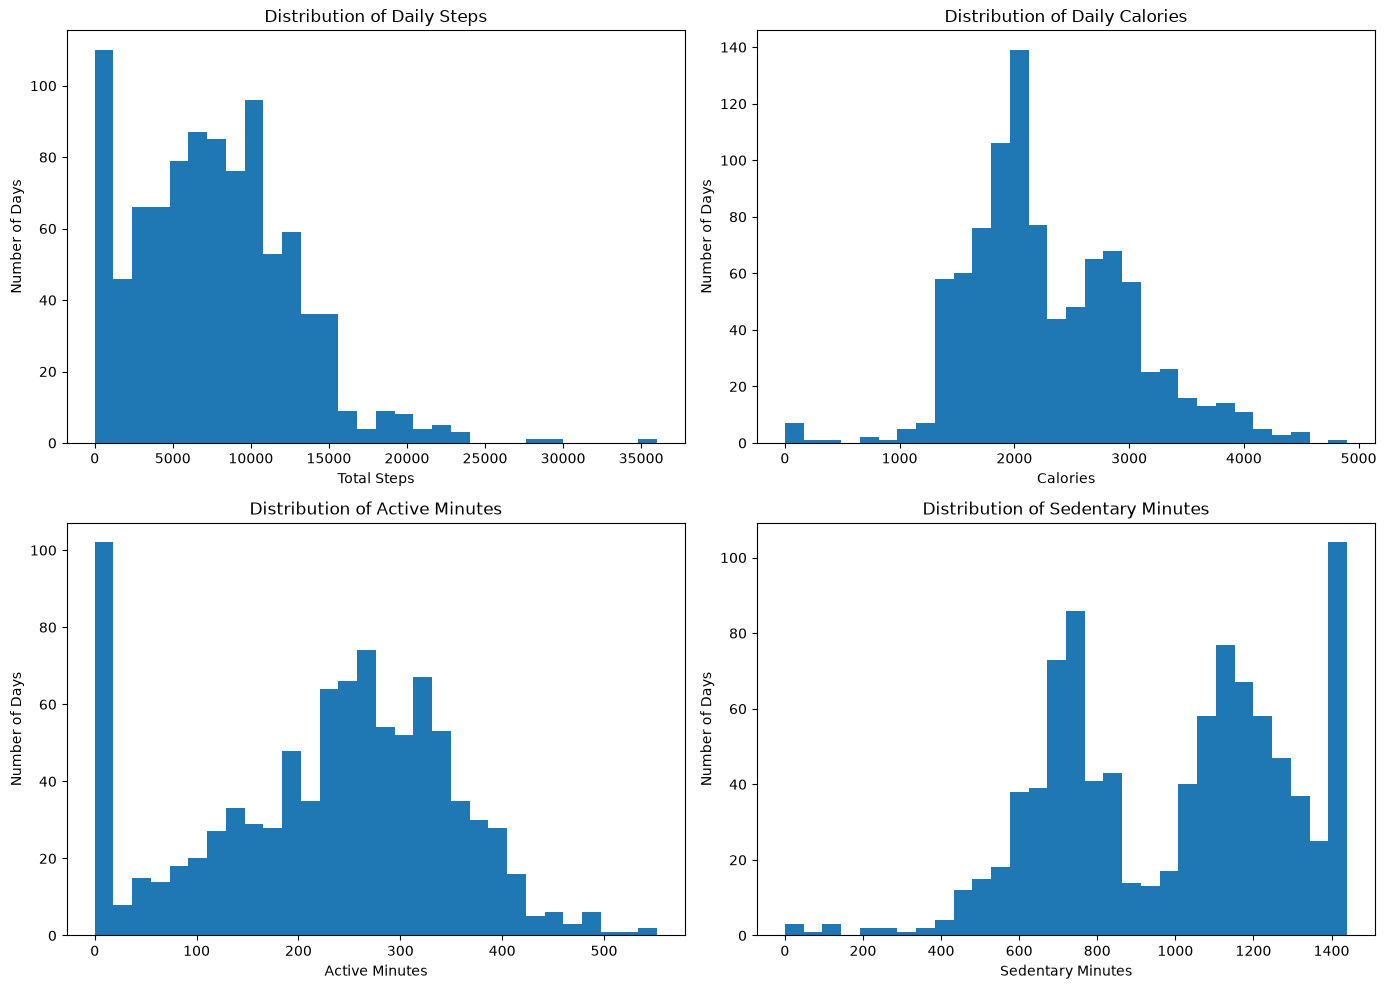

In [3]:
# =========================================================
# DAILY ACTIVITY EDA — DISTRIBUTIONS
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(daily["total_steps"], bins=30)
axes[0, 0].set_title("Distribution of Daily Steps")
axes[0, 0].set_xlabel("Total Steps")
axes[0, 0].set_ylabel("Number of Days")

axes[0, 1].hist(daily["calories"], bins=30)
axes[0, 1].set_title("Distribution of Daily Calories")
axes[0, 1].set_xlabel("Calories")
axes[0, 1].set_ylabel("Number of Days")

axes[1, 0].hist(daily["total_active_minutes"], bins=30)
axes[1, 0].set_title("Distribution of Active Minutes")
axes[1, 0].set_xlabel("Active Minutes")
axes[1, 0].set_ylabel("Number of Days")

axes[1, 1].hist(daily["sedentary_minutes"], bins=30)
axes[1, 1].set_title("Distribution of Sedentary Minutes")
axes[1, 1].set_xlabel("Sedentary Minutes")
axes[1, 1].set_ylabel("Number of Days")

plt.tight_layout()
plt.show()

In [4]:
# =========================================================
# WEEKDAY VS WEEKEND ACTIVITY
# =========================================================

weekday_summary = (
    daily.groupby("day_type")
    .agg(
        avg_steps=("total_steps", "mean"),
        avg_calories=("calories", "mean"),
        avg_active_minutes=("total_active_minutes", "mean"),
        avg_sedentary_minutes=("sedentary_minutes", "mean")
    )
    .round(2)
)

display(weekday_summary)

,avg_steps,avg_calories,avg_active_minutes,avg_sedentary_minutes
day_type,,,,
Weekday,7668.70,2301.52,227.88,996.18
Weekend,7550.57,2309.55,226.60,977.11


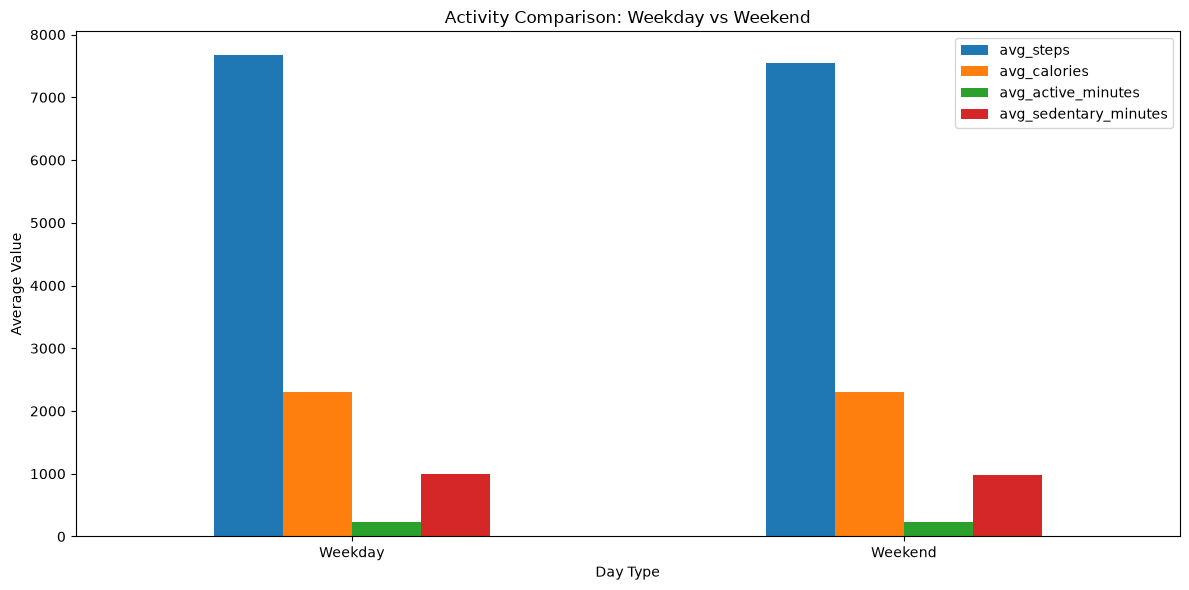

In [5]:
# Visual comparison

weekday_summary[
    ["avg_steps", "avg_calories", "avg_active_minutes", "avg_sedentary_minutes"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Activity Comparison: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# =========================================================
# ACTIVITY BY DAY OF WEEK
# =========================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_summary = (
    daily.groupby("day_name")
    .agg(
        avg_steps=("total_steps", "mean"),
        avg_calories=("calories", "mean"),
        avg_active_minutes=("total_active_minutes", "mean"),
        avg_sedentary_minutes=("sedentary_minutes", "mean")
    )
    .reindex(day_order)
    .round(2)
)

display(day_summary)

,avg_steps,avg_calories,avg_active_minutes,avg_sedentary_minutes
day_name,,,,
Monday,7780.87,2324.21,229.17,1027.94
Tuesday,8125.01,2356.01,234.63,1007.36
Wednesday,7559.37,2302.62,223.73,989.48
Thursday,7405.84,2199.57,216.79,961.99
Friday,7448.23,2331.79,236.37,1000.31
Saturday,8152.98,2354.97,244.27,964.28
Sunday,6933.23,2263.00,208.49,990.26


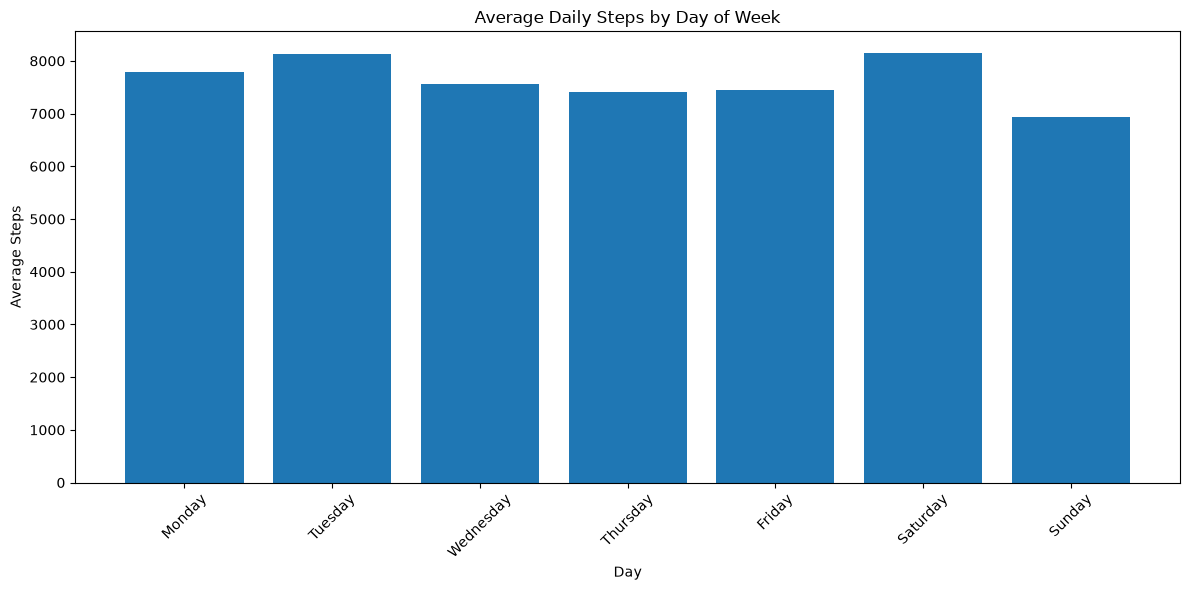

In [7]:
plt.figure(figsize=(12, 6))

plt.bar(
    day_summary.index,
    day_summary["avg_steps"]
)

plt.title("Average Daily Steps by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Steps")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

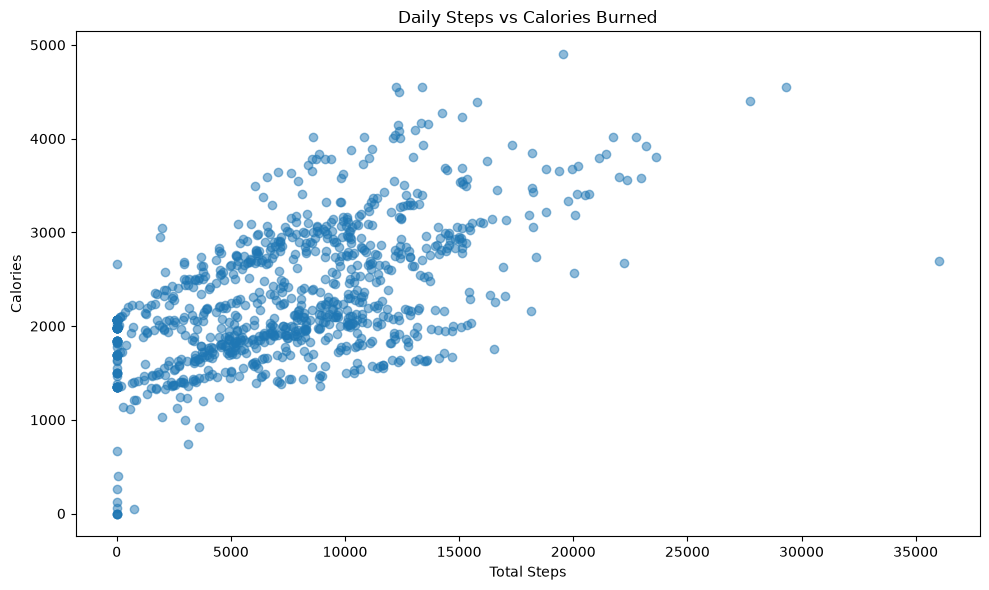

,total_steps,calories
total_steps,1.000,0.592
calories,0.592,1.000


In [8]:
# =========================================================
# STEPS VS CALORIES
# =========================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    daily["total_steps"],
    daily["calories"],
    alpha=0.5
)

plt.title("Daily Steps vs Calories Burned")
plt.xlabel("Total Steps")
plt.ylabel("Calories")

plt.tight_layout()
plt.show()

correlation = daily[
    ["total_steps", "calories"]
].corr()

display(correlation.round(3))

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure dates are properly formatted
daily["activity_date"] = pd.to_datetime(daily["activity_date"])

# ---------------------------------------------------------
# 1. Steps vs Calories
# ---------------------------------------------------------

steps_calories_corr = daily[
    ["total_steps", "calories"]
].corr().iloc[0, 1]

print(f"Steps vs Calories correlation: {steps_calories_corr:.3f}")


# ---------------------------------------------------------
# 2. Steps vs Active Minutes
# ---------------------------------------------------------

steps_active_corr = daily[
    ["total_steps", "total_active_minutes"]
].corr().iloc[0, 1]

print(f"Steps vs Active Minutes correlation: {steps_active_corr:.3f}")


# ---------------------------------------------------------
# 3. Active Minutes vs Calories
# ---------------------------------------------------------

active_calories_corr = daily[
    ["total_active_minutes", "calories"]
].corr().iloc[0, 1]

print(f"Active Minutes vs Calories correlation: {active_calories_corr:.3f}")


# ---------------------------------------------------------
# 4. Sedentary Minutes vs Calories
# ---------------------------------------------------------

sedentary_calories_corr = daily[
    ["sedentary_minutes", "calories"]
].corr().iloc[0, 1]

print(f"Sedentary Minutes vs Calories correlation: {sedentary_calories_corr:.3f}")


# ---------------------------------------------------------
# 5. Daily activity categories
# ---------------------------------------------------------

activity_summary = daily[
    [
        "total_steps",
        "total_active_minutes",
        "sedentary_minutes",
        "calories"
    ]
].describe()

display(activity_summary)


# ---------------------------------------------------------
# 6. Identify high / low activity days
# ---------------------------------------------------------

print("\nTop 10 days by steps:")

top_steps = daily[
    ["id", "activity_date", "total_steps", "calories", "total_active_minutes"]
].sort_values(
    "total_steps",
    ascending=False
).head(10)

display(top_steps)


print("\nBottom 10 days by steps:")

bottom_steps = daily[
    ["id", "activity_date", "total_steps", "calories", "total_active_minutes"]
].sort_values(
    "total_steps",
    ascending=True
).head(10)

display(bottom_steps)

Steps vs Calories correlation: 0.592
Steps vs Active Minutes correlation: 0.772
Active Minutes vs Calories correlation: 0.472
Sedentary Minutes vs Calories correlation: -0.107


,total_steps,total_active_minutes,sedentary_minutes,calories
count,940.000000,940.000000,940.000000,940.000000
mean,7637.910638,227.542553,991.210638,2303.609574
std,5087.150742,121.776307,301.267437,718.166862
min,0.000000,0.000000,0.000000,0.000000
25%,3789.750000,146.750000,729.750000,1828.500000
50%,7405.500000,247.000000,1057.500000,2134.000000
75%,10727.000000,317.250000,1229.500000,2793.250000
max,36019.000000,552.000000,1440.000000,4900.000000



Top 10 days by steps:


,id,activity_date,total_steps,calories,total_active_minutes
50,1624580081,2016-05-01,36019,2690,420
913,8877689391,2016-04-16,29326,4547,552
927,8877689391,2016-04-30,27745,4398,351
924,8877689391,2016-04-27,23629,3808,336
909,8877689391,2016-04-12,23186,3921,404
780,8053475328,2016-04-24,22988,3577,344
437,4388161847,2016-05-07,22770,4022,436
779,8053475328,2016-04-23,22359,3554,362
251,2347167796,2016-04-16,22244,2670,406
794,8053475328,2016-05-08,22026,3589,367



Bottom 10 days by steps:


,id,activity_date,total_steps,calories,total_active_minutes
908,8792009665,2016-05-10,0,57,0
654,6775888955,2016-04-12,0,1841,0
642,6290855005,2016-04-29,0,2060,0
30,1503960366,2016-05-12,0,0,0
893,8792009665,2016-04-25,0,1688,0
742,7086361926,2016-04-17,0,1629,0
347,4020332650,2016-04-13,0,1981,0
610,6117666160,2016-04-25,0,1497,0
104,1844505072,2016-04-24,0,1347,0
663,6775888955,2016-04-21,0,1841,0


Hourly Activity Summary:


,avg_steps,avg_calories,avg_intensity,avg_total_intensity
hour,,,,
0,42.19,71.81,0.04,2.13
1,23.10,70.17,0.02,1.42
2,17.11,69.19,0.02,1.04
3,6.43,67.54,0.01,0.44
4,12.70,68.26,0.01,0.63
5,43.87,81.71,0.08,4.95
6,178.51,87.00,0.13,7.77
7,306.05,94.48,0.18,10.73
8,427.54,103.34,0.24,14.67


Top 10 hours by average steps:


,avg_steps,avg_calories,avg_intensity,avg_total_intensity
hour,,,,
18,599.17,123.49,0.37,21.92
19,583.39,121.48,0.36,21.39
17,550.23,122.75,0.36,21.66
12,548.64,117.20,0.33,19.85
14,540.51,115.73,0.31,18.87
13,537.70,115.31,0.31,18.78
16,496.85,113.33,0.30,17.72
10,481.67,110.46,0.29,17.64
11,456.89,109.81,0.28,16.92


Lowest 10 hours by average steps:


,avg_steps,avg_calories,avg_intensity,avg_total_intensity
hour,,,,
3,6.43,67.54,0.01,0.44
4,12.70,68.26,0.01,0.63
2,17.11,69.19,0.02,1.04
1,23.10,70.17,0.02,1.42
0,42.19,71.81,0.04,2.13
5,43.87,81.71,0.08,4.95
23,122.13,77.59,0.08,5.00
6,178.51,87.00,0.13,7.77
22,237.99,88.27,0.15,9.06


Hourly Weekday vs Weekend:


avg_steps  avg_calories  avg_intensity
hour day_type                                        
0    Weekday       32.78         70.76           0.03
     Weekend       68.79         74.75           0.05
1    Weekday       18.67         69.26           0.02
     Weekend       35.70         72.73           0.04
2    Weekday       12.03         68.37           0.01
     Weekend       31.53         71.51           0.03
3    Weekday        6.18         67.46           0.01
     Weekend        7.14         67.77           0.01
4    Weekday       14.41         68.48           0.01
     Weekend        7.85         67.63           0.01
5    Weekday       54.57         86.61           0.11
     Weekend       13.51         67.82           0.01
6    Weekday      219.54         91.97           0.16
     Weekend       62.34         72.92           0.05
7    Weekday      349.23         98.00           0.20
     Weekend      183.79         84.51           0.12
8    Weekday      449.42        105.05           0.26
     Weekend      365.60         98.49           0.21
9    Weekday      423.58        104.68           0.25
     Weekend      460.81        110.28           0.28

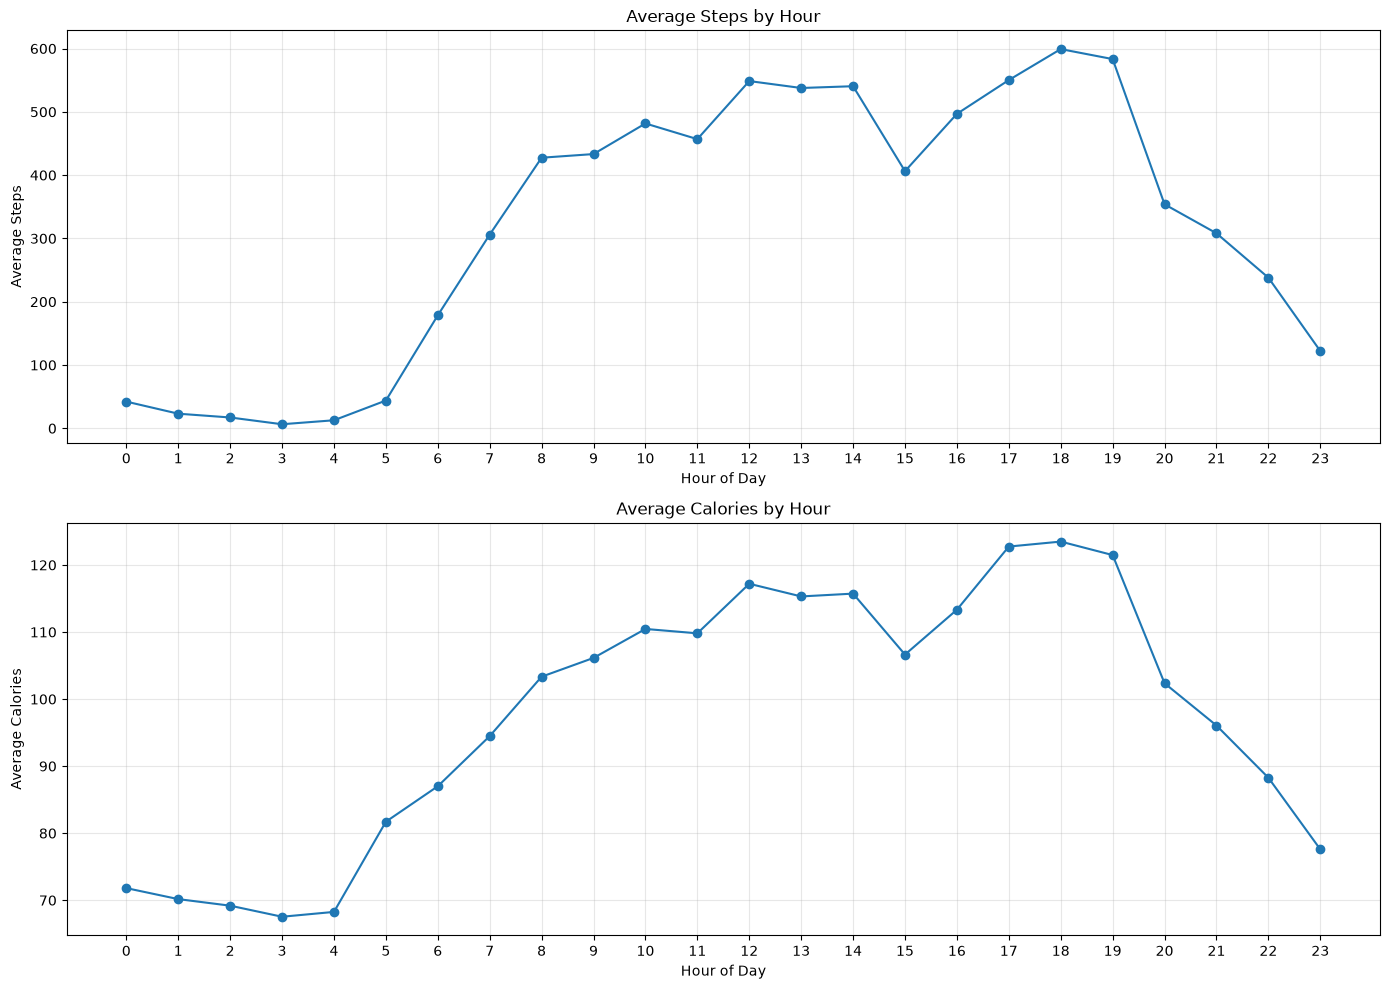

In [10]:
# ============================================================
# HOURLY ACTIVITY EDA
# ============================================================

hourly["activity_hour"] = pd.to_datetime(hourly["activity_hour"])

# Extract useful time features
hourly["hour"] = hourly["activity_hour"].dt.hour
hourly["day_name"] = hourly["activity_hour"].dt.day_name()
hourly["day_type"] = hourly["activity_hour"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

# ------------------------------------------------------------
# 1. Overall hourly activity
# ------------------------------------------------------------

hourly_summary = (
    hourly
    .groupby("hour")
    .agg(
        avg_steps=("step_total", "mean"),
        avg_calories=("calories", "mean"),
        avg_intensity=("average_intensity", "mean"),
        avg_total_intensity=("total_intensity", "mean")
    )
    .round(2)
)

print("Hourly Activity Summary:")
display(hourly_summary)


# ------------------------------------------------------------
# 2. Peak hours
# ------------------------------------------------------------

print("Top 10 hours by average steps:")

top_hours = (
    hourly_summary
    .sort_values("avg_steps", ascending=False)
    .head(10)
)

display(top_hours)


# ------------------------------------------------------------
# 3. Lowest activity hours
# ------------------------------------------------------------

print("Lowest 10 hours by average steps:")

low_hours = (
    hourly_summary
    .sort_values("avg_steps", ascending=True)
    .head(10)
)

display(low_hours)


# ------------------------------------------------------------
# 4. Weekday vs Weekend by hour
# ------------------------------------------------------------

hourly_daytype = (
    hourly
    .groupby(["hour", "day_type"])
    .agg(
        avg_steps=("step_total", "mean"),
        avg_calories=("calories", "mean"),
        avg_intensity=("average_intensity", "mean")
    )
    .round(2)
)

print("Hourly Weekday vs Weekend:")
display(hourly_daytype.head(20))


# ------------------------------------------------------------
# 5. Overall hourly plots
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

hourly_summary["avg_steps"].plot(
    kind="line",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Average Steps by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Steps")
axes[0].set_xticks(range(24))
axes[0].grid(True, alpha=0.3)

hourly_summary["avg_calories"].plot(
    kind="line",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Average Calories by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Average Calories")
axes[1].set_xticks(range(24))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Overall Sleep Statistics:


,sleep_hours,time_in_bed_hours,total_minutes_asleep,total_time_in_bed
count,410.00,410.00,410.00,410.00
mean,6.99,7.64,419.17,458.48
std,1.98,2.12,118.64,127.46
min,0.97,1.02,58.00,61.00
25%,6.02,6.73,361.00,403.75
50%,7.21,7.72,432.50,463.00
75%,8.17,8.77,490.00,526.00
max,13.27,16.02,796.00,961.00


Sleep: Weekday vs Weekend:


,avg_sleep_hours,avg_time_in_bed,avg_sleep_minutes
day_type,,,
Weekday,6.88,7.50,413.00
Weekend,7.26,8.02,435.61


Sleep by Day of Week:


...

calories               -0.032
total_active_minutes   -0.069
total_steps            -0.190
sedentary_minutes      -0.601
Name: sleep_hours, dtype: float64

Users with lowest average sleep:


,avg_sleep_hours,avg_time_in_bed,sleep_records
id,,,
2320127002,1.02,1.15,1
7007744171,1.14,1.19,2
4558609924,2.13,2.33,5
3977333714,4.89,7.69,28
1644430081,4.90,5.77,4
8053475328,4.95,5.03,3
4020332650,5.82,6.33,8
6775888955,5.83,6.15,3
1503960366,6.00,6.39,25


Users with highest average sleep:


,avg_sleep_hours,avg_time_in_bed,sleep_records
id,,,
8792009665,7.26,7.56,15
8378563200,7.42,8.10,31
2347167796,7.45,8.19,15
6962181067,7.47,7.77,31
7086361926,7.55,7.77,24
5553957443,7.72,8.43,31
4319703577,7.94,8.37,26
6117666160,7.98,8.50,18
2026352035,8.44,8.96,28


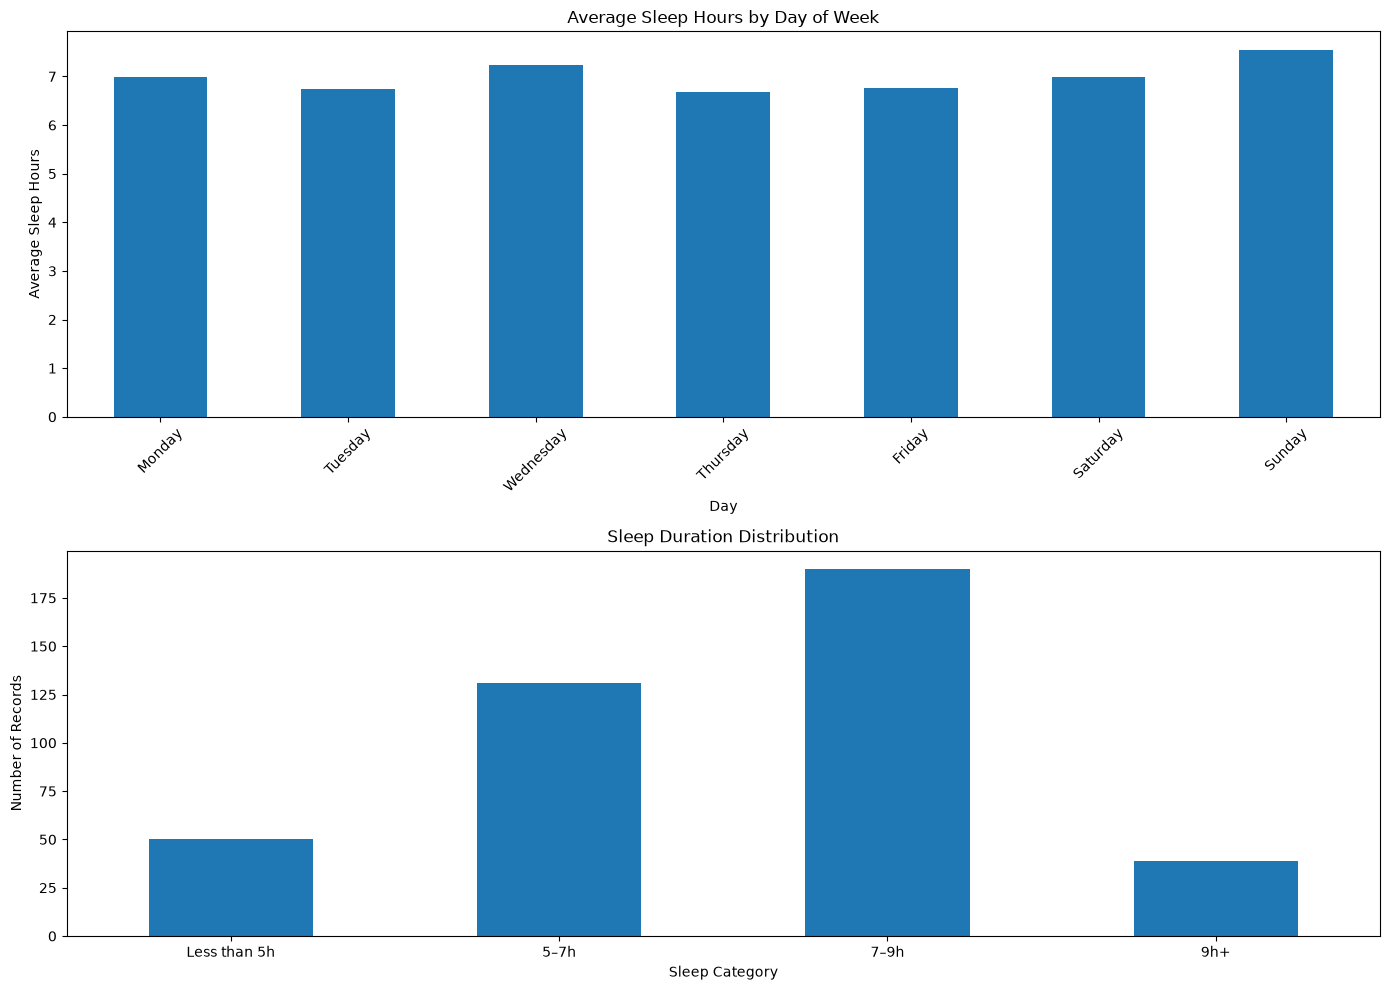

In [11]:
# ============================================================
# SLEEP EDA
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Make sure dates are correct
sleep["activity_date"] = pd.to_datetime(sleep["activity_date"])

# Create day information
sleep["day_name"] = sleep["activity_date"].dt.day_name()
sleep["day_type"] = sleep["activity_date"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

# ------------------------------------------------------------
# 1. Overall Sleep Statistics
# ------------------------------------------------------------

sleep_stats = sleep[
    [
        "sleep_hours",
        "time_in_bed_hours",
        "total_minutes_asleep",
        "total_time_in_bed"
    ]
].describe().round(2)

print("Overall Sleep Statistics:")
display(sleep_stats)


# ------------------------------------------------------------
# 2. Sleep by Day Type
# ------------------------------------------------------------

sleep_daytype = (
    sleep
    .groupby("day_type")
    .agg(
        avg_sleep_hours=("sleep_hours", "mean"),
        avg_time_in_bed=("time_in_bed_hours", "mean"),
        avg_sleep_minutes=("total_minutes_asleep", "mean")
    )
    .round(2)
)

print("Sleep: Weekday vs Weekend:")
display(sleep_daytype)


# ------------------------------------------------------------
# 3. Sleep by Day of Week
# ------------------------------------------------------------

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

sleep_day = (
    sleep
    .groupby("day_name")
    .agg(
        avg_sleep_hours=("sleep_hours", "mean"),
        avg_time_in_bed=("time_in_bed_hours", "mean")
    )
    .reindex(day_order)
    .round(2)
)

print("Sleep by Day of Week:")
display(sleep_day)


# ------------------------------------------------------------
# 4. Sleep Distribution Categories
# ------------------------------------------------------------

def sleep_category(hours):
    if hours < 5:
        return "Less than 5h"
    elif hours < 7:
        return "5–7h"
    elif hours < 9:
        return "7–9h"
    else:
        return "9h+"

sleep["sleep_category"] = sleep["sleep_hours"].apply(sleep_category)

sleep_distribution = (
    sleep["sleep_category"]
    .value_counts()
    .reindex(
        ["Less than 5h", "5–7h", "7–9h", "9h+"],
        fill_value=0
    )
)

print("Sleep Duration Categories:")
display(sleep_distribution)


# ------------------------------------------------------------
# 5. Sleep vs Activity — Merge only for analysis
# ------------------------------------------------------------

sleep_activity = pd.merge(
    daily[
        [
            "id",
            "activity_date",
            "total_steps",
            "calories",
            "total_active_minutes",
            "sedentary_minutes"
        ]
    ],
    sleep[
        [
            "id",
            "activity_date",
            "sleep_hours",
            "time_in_bed_hours"
        ]
    ],
    on=["id", "activity_date"],
    how="inner"
)

print("\nActivity + Sleep overlap:")
print(f"Rows: {len(sleep_activity):,}")
print(f"Users: {sleep_activity['id'].nunique()}")


# ------------------------------------------------------------
# 6. Correlations
# ------------------------------------------------------------

sleep_correlations = (
    sleep_activity[
        [
            "sleep_hours",
            "total_steps",
            "calories",
            "total_active_minutes",
            "sedentary_minutes"
        ]
    ]
    .corr()["sleep_hours"]
    .drop("sleep_hours")
    .sort_values(ascending=False)
    .round(3)
)

print("\nCorrelation with Sleep Hours:")
display(sleep_correlations)


# ------------------------------------------------------------
# 7. User-level Sleep Summary
# ------------------------------------------------------------

user_sleep = (
    sleep
    .groupby("id")
    .agg(
        avg_sleep_hours=("sleep_hours", "mean"),
        avg_time_in_bed=("time_in_bed_hours", "mean"),
        sleep_records=("activity_date", "count")
    )
    .sort_values("avg_sleep_hours")
    .round(2)
)

print("Users with lowest average sleep:")
display(user_sleep.head(10))

print("Users with highest average sleep:")
display(user_sleep.tail(10))


# ------------------------------------------------------------
# 8. Visualizations
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Sleep by day
sleep_day["avg_sleep_hours"].plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Average Sleep Hours by Day of Week")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Average Sleep Hours")
axes[0].tick_params(axis="x", rotation=45)

# Sleep distribution
sleep_distribution.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Sleep Duration Distribution")
axes[1].set_xlabel("Sleep Category")
axes[1].set_ylabel("Number of Records")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# FINAL CORE MERGE: DAILY ACTIVITY + SLEEP
# ============================================================

# Select only the columns needed for analysis
activity_core = daily[
    [
        "id",
        "activity_date",
        "total_steps",
        "total_distance",
        "very_active_minutes",
        "fairly_active_minutes",
        "lightly_active_minutes",
        "sedentary_minutes",
        "total_active_minutes",
        "calories",
        "complete_day",
        "zero_activity_day"
    ]
].copy()

sleep_core = sleep[
    [
        "id",
        "activity_date",
        "sleep_hours",
        "time_in_bed_hours",
        "total_sleep_records"
    ]
].copy()

# Make sure merge keys have identical types
activity_core["id"] = activity_core["id"].astype(str)
sleep_core["id"] = sleep_core["id"].astype(str)

activity_core["activity_date"] = pd.to_datetime(
    activity_core["activity_date"]
)

sleep_core["activity_date"] = pd.to_datetime(
    sleep_core["activity_date"]
)

# ------------------------------------------------------------
# Validate duplicate keys BEFORE merge
# ------------------------------------------------------------

activity_duplicates = activity_core.duplicated(
    ["id", "activity_date"]
).sum()

sleep_duplicates = sleep_core.duplicated(
    ["id", "activity_date"]
).sum()

print("Duplicate activity keys:", activity_duplicates)
print("Duplicate sleep keys:", sleep_duplicates)

# ------------------------------------------------------------
# Merge
# ------------------------------------------------------------

activity_sleep = pd.merge(
    activity_core,
    sleep_core,
    on=["id", "activity_date"],
    how="inner"
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("\n========== MERGED TABLE VALIDATION ==========")

print("Rows:", len(activity_sleep))
print("Users:", activity_sleep["id"].nunique())
print(
    "Date range:",
    activity_sleep["activity_date"].min().date(),
    "to",
    activity_sleep["activity_date"].max().date()
)

print(
    "Duplicate user-date keys:",
    activity_sleep.duplicated(["id", "activity_date"]).sum()
)

print(
    "Missing values:",
    activity_sleep.isna().sum().sum()
)

print("\nColumns:")
print(activity_sleep.columns.tolist())

display(activity_sleep.head())

Duplicate activity keys: 0
Duplicate sleep keys: 0

========== MERGED TABLE VALIDATION ==========
Rows: 410
Users: 24
Date range: 2016-04-12 to 2016-05-12
Duplicate user-date keys: 0
Missing values: 0

Columns:
['id', 'activity_date', 'total_steps', 'total_distance', 'very_active_minutes', 'fairly_active_minutes', 'lightly_active_minutes', 'sedentary_minutes', 'total_active_minutes', 'calories', 'complete_day', 'zero_activity_day', 'sleep_hours', 'time_in_bed_hours', 'total_sleep_records']


,id,activity_date,total_steps,total_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,total_active_minutes,calories,complete_day,zero_activity_day,sleep_hours,time_in_bed_hours,total_sleep_records
0,1503960366,2016-04-12,13162,8.50,25,13,328,728,366,1985,False,False,5.450000,5.766667,1
1,1503960366,2016-04-13,10735,6.97,21,19,217,776,257,1797,False,False,6.400000,6.783333,2
2,1503960366,2016-04-15,9762,6.28,29,34,209,726,272,1745,False,False,6.866667,7.366667,1
3,1503960366,2016-04-16,12669,8.16,36,10,221,773,267,1863,False,False,5.666667,6.116667,2
4,1503960366,2016-04-17,9705,6.48,38,20,164,539,222,1728,False,False,11.666667,11.866667,1


Activity + Sleep Statistics:


,total_steps,calories,total_active_minutes,sedentary_minutes,sleep_hours,time_in_bed_hours
count,410.00,410.00,410.00,410.00,410.00,410.00
mean,8514.91,2389.30,259.51,712.10,6.99,7.64
std,4157.38,758.44,92.17,166.18,1.98,2.12
min,17.00,257.00,2.00,0.00,0.97,1.02
25%,5188.75,1841.00,206.50,631.25,6.02,6.73
50%,8913.00,2207.00,263.50,717.00,7.21,7.72
75%,11370.25,2920.00,315.50,782.75,8.17,8.77
max,22770.00,4900.00,540.00,1265.00,13.27,16.02


Activity + Sleep Correlation Matrix:


,sleep_hours,total_steps,calories,total_active_minutes,sedentary_minutes,time_in_bed_hours
sleep_hours,1.000,-0.190,-0.032,-0.069,-0.601,0.930
total_steps,-0.190,1.000,0.406,0.745,-0.130,-0.166
calories,-0.032,0.406,1.000,0.390,0.099,-0.135
total_active_minutes,-0.069,0.745,0.390,1.000,-0.263,-0.098
sedentary_minutes,-0.601,-0.130,0.099,-0.263,1.000,-0.620
time_in_bed_hours,0.930,-0.166,-0.135,-0.098,-0.620,1.000


Activity by Sleep Duration Group:


,records,avg_steps,avg_calories,avg_active_minutes,avg_sedentary_minutes,avg_sleep_hours
sleep_group,,,,,,
Less than 5h,50,9724.42,2191.84,263.58,915.04,3.20
5–7h,131,9225.05,2499.02,266.02,733.15,6.18
7–9h,190,8176.80,2396.52,261.38,674.58,7.89
9h+,39,6226.13,2238.72,223.33,564.00,10.17


Activity + Sleep: Weekday vs Weekend:


,avg_steps,avg_calories,avg_active_minutes,avg_sedentary_minutes,avg_sleep_hours,avg_time_in_bed
day_type,,,,,,
Weekday,8480.12,2387.6,256.13,722.67,6.88,7.50
Weekend,8607.46,2393.8,268.52,683.97,7.26,8.02


Combined Day-of-Week Analysis:


,avg_steps,avg_calories,avg_active_minutes,avg_sedentary_minutes,avg_sleep_hours
day_name,,,,,
Monday,9273.22,2431.98,272.17,718.41,6.99
Tuesday,9182.69,2496.20,267.25,740.05,6.74
Wednesday,8022.86,2378.24,246.05,714.45,7.24
Thursday,8183.52,2306.67,241.66,698.38,6.69
Friday,7901.40,2329.65,258.42,743.09,6.76
Saturday,9871.12,2506.89,297.05,680.44,6.98
Sunday,7297.85,2276.60,238.95,687.64,7.55


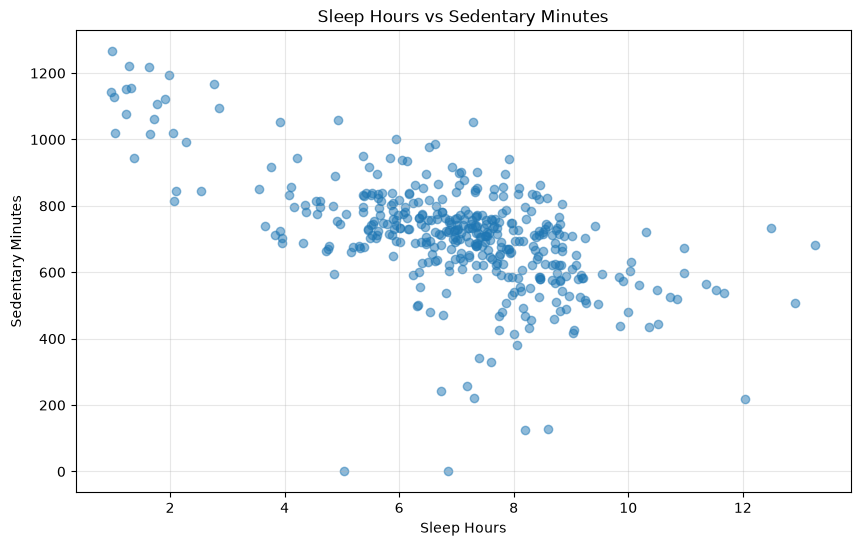

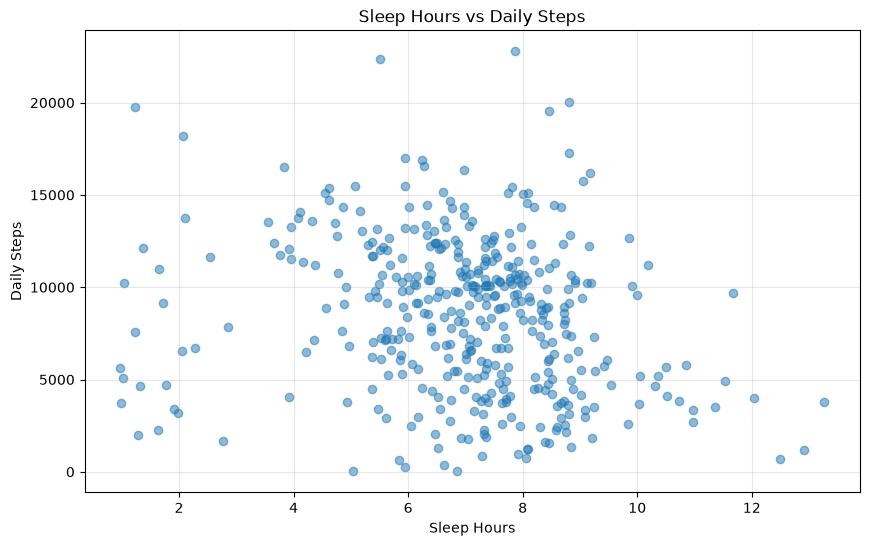

In [13]:
# ============================================================
# FINAL CROSS-DATASET EDA
# ACTIVITY + SLEEP
# ============================================================

# ------------------------------------------------------------
# 1. Overall merged statistics
# ------------------------------------------------------------

merged_stats = activity_sleep[
    [
        "total_steps",
        "calories",
        "total_active_minutes",
        "sedentary_minutes",
        "sleep_hours",
        "time_in_bed_hours"
    ]
].describe().round(2)

print("Activity + Sleep Statistics:")
display(merged_stats)


# ------------------------------------------------------------
# 2. Sleep vs Activity correlation matrix
# ------------------------------------------------------------

correlation_matrix = activity_sleep[
    [
        "sleep_hours",
        "total_steps",
        "calories",
        "total_active_minutes",
        "sedentary_minutes",
        "time_in_bed_hours"
    ]
].corr().round(3)

print("Activity + Sleep Correlation Matrix:")
display(correlation_matrix)


# ------------------------------------------------------------
# 3. Sleep categories vs activity
# ------------------------------------------------------------

sleep_category_summary = (
    activity_sleep
    .groupby("sleep_category" if "sleep_category" in activity_sleep.columns else "sleep_hours")
)

# Create categories specifically for merged data
activity_sleep["sleep_group"] = pd.cut(
    activity_sleep["sleep_hours"],
    bins=[0, 5, 7, 9, float("inf")],
    labels=["Less than 5h", "5–7h", "7–9h", "9h+"],
    right=False
)

sleep_group_analysis = (
    activity_sleep
    .groupby("sleep_group", observed=False)
    .agg(
        records=("id", "count"),
        avg_steps=("total_steps", "mean"),
        avg_calories=("calories", "mean"),
        avg_active_minutes=("total_active_minutes", "mean"),
        avg_sedentary_minutes=("sedentary_minutes", "mean"),
        avg_sleep_hours=("sleep_hours", "mean")
    )
    .round(2)
)

print("Activity by Sleep Duration Group:")
display(sleep_group_analysis)


# ------------------------------------------------------------
# 4. Weekday vs Weekend: Activity + Sleep
# ------------------------------------------------------------

activity_sleep["day_name"] = (
    activity_sleep["activity_date"].dt.day_name()
)

activity_sleep["day_type"] = (
    activity_sleep["activity_date"]
    .dt.dayofweek
    .map(lambda x: "Weekend" if x >= 5 else "Weekday")
)

daytype_analysis = (
    activity_sleep
    .groupby("day_type")
    .agg(
        avg_steps=("total_steps", "mean"),
        avg_calories=("calories", "mean"),
        avg_active_minutes=("total_active_minutes", "mean"),
        avg_sedentary_minutes=("sedentary_minutes", "mean"),
        avg_sleep_hours=("sleep_hours", "mean"),
        avg_time_in_bed=("time_in_bed_hours", "mean")
    )
    .round(2)
)

print("Activity + Sleep: Weekday vs Weekend:")
display(daytype_analysis)


# ------------------------------------------------------------
# 5. Day-of-week combined analysis
# ------------------------------------------------------------

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_analysis = (
    activity_sleep
    .groupby("day_name")
    .agg(
        avg_steps=("total_steps", "mean"),
        avg_calories=("calories", "mean"),
        avg_active_minutes=("total_active_minutes", "mean"),
        avg_sedentary_minutes=("sedentary_minutes", "mean"),
        avg_sleep_hours=("sleep_hours", "mean")
    )
    .reindex(day_order)
    .round(2)
)

print("Combined Day-of-Week Analysis:")
display(day_analysis)


# ------------------------------------------------------------
# 6. Sleep vs Sedentary scatter
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    activity_sleep["sleep_hours"],
    activity_sleep["sedentary_minutes"],
    alpha=0.5
)

plt.title("Sleep Hours vs Sedentary Minutes")
plt.xlabel("Sleep Hours")
plt.ylabel("Sedentary Minutes")
plt.grid(True, alpha=0.3)

plt.show()


# ------------------------------------------------------------
# 7. Sleep vs Steps scatter
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    activity_sleep["sleep_hours"],
    activity_sleep["total_steps"],
    alpha=0.5
)

plt.title("Sleep Hours vs Daily Steps")
plt.xlabel("Sleep Hours")
plt.ylabel("Daily Steps")
plt.grid(True, alpha=0.3)

plt.show()

In [14]:
# ============================================================
# SAVE FINAL ANALYTICAL TABLE
# ============================================================

output_file = CLEAN_FOLDER / "activity_sleep_merged.csv"

activity_sleep.to_csv(
    output_file,
    index=False
)

print("Saved successfully:")
print(output_file)

print("\nFinal shape:")
print(activity_sleep.shape)

print("\nFinal users:")
print(activity_sleep["id"].nunique())

print("\nDuplicate user-date keys:")
print(
    activity_sleep.duplicated(
        ["id", "activity_date"]
    ).sum()
)

Saved successfully:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\activity_sleep_merged.csv

Final shape:
(410, 18)

Final users:
24

Duplicate user-date keys:
0


In [1]:
!pip install duckdb

   ---------------------------------------- 0.0/13.7 MB ? eta -:--:--
   ---------- ----------------------------- 3.7/13.7 MB 20.8 MB/s eta 0:00:01
   ------------------ --------------------- 6.3/13.7 MB 16.5 MB/s eta 0:00:01
   ------------------------- -------------- 8.7/13.7 MB 15.3 MB/s eta 0:00:01
   --------------------------------- ------ 11.5/13.7 MB 14.6 MB/s eta 0:00:01
   ---------------------------------------- 13.7/13.7 MB 13.9 MB/s  0:00:01


In [2]:
import duckdb
import pandas as pd
from pathlib import Path

# Existing project folder
CLEAN_FOLDER = Path(r"C:\Users\Eklavya\Desktop\strava fitness\cleaned_data")

# SQL database file
DB_PATH = CLEAN_FOLDER / "fitness_analytics.duckdb"

# Connect
con = duckdb.connect(str(DB_PATH))

print("Database created/connected:")
print(DB_PATH)

Database created/connected:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\fitness_analytics.duckdb


In [3]:
daily = pd.read_csv(CLEAN_FOLDER / "daily_activity_master.csv")
hourly = pd.read_csv(CLEAN_FOLDER / "hourly_activity_master.csv")
sleep = pd.read_csv(CLEAN_FOLDER / "sleep_daily_master.csv")
activity_sleep = pd.read_csv(CLEAN_FOLDER / "activity_sleep_merged.csv")

# Convert dates
daily["activity_date"] = pd.to_datetime(daily["activity_date"])
hourly["activity_hour"] = pd.to_datetime(hourly["activity_hour"])
sleep["activity_date"] = pd.to_datetime(sleep["activity_date"])
activity_sleep["activity_date"] = pd.to_datetime(activity_sleep["activity_date"])

# Register DataFrames in DuckDB
con.register("daily_df", daily)
con.register("hourly_df", hourly)
con.register("sleep_df", sleep)
con.register("activity_sleep_df", activity_sleep)

# Create SQL tables
con.execute("""
CREATE OR REPLACE TABLE daily_activity AS
SELECT * FROM daily_df
""")

con.execute("""
CREATE OR REPLACE TABLE hourly_activity AS
SELECT * FROM hourly_df
""")

con.execute("""
CREATE OR REPLACE TABLE sleep_daily AS
SELECT * FROM sleep_df
""")

con.execute("""
CREATE OR REPLACE TABLE activity_sleep AS
SELECT * FROM activity_sleep_df
""")

print("All 4 SQL tables created successfully.")

All 4 SQL tables created successfully.


In [4]:
tables = con.execute("SHOW TABLES").df()

tables

,name
0,activity_sleep
1,activity_sleep_df
2,daily_activity
3,daily_df
4,hourly_activity
5,hourly_df
6,sleep_daily
7,sleep_df


In [5]:
validation = con.execute("""
SELECT 'daily_activity' AS table_name, COUNT(*) AS rows
FROM daily_activity

UNION ALL

SELECT 'hourly_activity', COUNT(*)
FROM hourly_activity

UNION ALL

SELECT 'sleep_daily', COUNT(*)
FROM sleep_daily

UNION ALL

SELECT 'activity_sleep', COUNT(*)
FROM activity_sleep
""").df()

validation

,table_name,rows
0,daily_activity,940
1,hourly_activity,22099
2,sleep_daily,410
3,activity_sleep,410


In [6]:
user_validation = con.execute("""
SELECT
    'daily_activity' AS table_name,
    COUNT(DISTINCT id) AS users
FROM daily_activity

UNION ALL

SELECT
    'hourly_activity',
    COUNT(DISTINCT id)
FROM hourly_activity

UNION ALL

SELECT
    'sleep_daily',
    COUNT(DISTINCT id)
FROM sleep_daily

UNION ALL

SELECT
    'activity_sleep',
    COUNT(DISTINCT id)
FROM activity_sleep
""").df()

user_validation

,table_name,users
0,daily_activity,33
1,hourly_activity,33
2,sleep_daily,24
3,activity_sleep,24


In [7]:
print("Daily duplicates:",
      con.execute("""
      SELECT COUNT(*)
      FROM (
          SELECT id, activity_date
          FROM daily_activity
          GROUP BY id, activity_date
          HAVING COUNT(*) > 1
      )
      """).fetchone()[0])

print("Hourly duplicates:",
      con.execute("""
      SELECT COUNT(*)
      FROM (
          SELECT id, activity_hour
          FROM hourly_activity
          GROUP BY id, activity_hour
          HAVING COUNT(*) > 1
      )
      """).fetchone()[0])

print("Sleep duplicates:",
      con.execute("""
      SELECT COUNT(*)
      FROM (
          SELECT id, activity_date
          FROM sleep_daily
          GROUP BY id, activity_date
          HAVING COUNT(*) > 1
      )
      """).fetchone()[0])

print("Activity-Sleep duplicates:",
      con.execute("""
      SELECT COUNT(*)
      FROM (
          SELECT id, activity_date
          FROM activity_sleep
          GROUP BY id, activity_date
          HAVING COUNT(*) > 1
      )
      """).fetchone()[0])

Daily duplicates: 0
Hourly duplicates: 0
Sleep duplicates: 0
Activity-Sleep duplicates: 0


In [8]:
for table in [
    "daily_activity",
    "hourly_activity",
    "sleep_daily",
    "activity_sleep"
]:
    print(f"\n{table}")

    result = con.execute(f"""
        SELECT *
        FROM {table}
        LIMIT 1
    """).df()

    null_counts = result.isnull().sum()

    # Get actual table columns
    columns = con.execute(f"""
        DESCRIBE {table}
    """).df()["column_name"].tolist()

    for col in columns:
        count = con.execute(f"""
            SELECT COUNT(*)
            FROM {table}
            WHERE "{col}" IS NULL
        """).fetchone()[0]

        if count > 0:
            print(col, ":", count)


daily_activity

hourly_activity

sleep_daily

activity_sleep


In [9]:
q3 = con.execute("""
SELECT
    id,
    ROUND(AVG(total_steps), 2) AS avg_daily_steps,
    ROUND(AVG(calories), 2) AS avg_daily_calories,
    ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes
FROM daily_activity
GROUP BY id
ORDER BY avg_daily_steps DESC
LIMIT 10
""").df()

q3

,id,avg_daily_steps,avg_daily_calories,avg_active_minutes
0,8877689391,16040.03,3420.26,310.71
1,8053475328,14763.29,2945.81,245.71
2,1503960366,12116.74,1816.42,277.81
3,2022484408,11370.65,2509.97,313.10
4,7007744171,11323.42,2544.00,328.04
5,3977333714,10984.57,1513.67,254.93
6,4388161847,10813.94,3093.87,272.87
7,6962181067,9794.81,1982.03,287.13
8,2347167796,9519.67,2043.44,286.56
9,7086361926,9371.77,2566.35,211.77


In [10]:
q6 = con.execute("""
SELECT
    day_type,
    COUNT(*) AS records,
    ROUND(AVG(total_steps), 2) AS avg_steps,
    ROUND(AVG(calories), 2) AS avg_calories,
    ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes,
    ROUND(AVG(sedentary_minutes), 2) AS avg_sedentary_minutes
FROM daily_activity
GROUP BY day_type
ORDER BY day_type
""").df()

q6

,day_type,records,avg_steps,avg_calories,avg_active_minutes,avg_sedentary_minutes
0,Weekday,695,7668.70,2301.52,227.88,996.18
1,Weekend,245,7550.57,2309.55,226.60,977.11


In [11]:
q13 = con.execute("""
SELECT
    CASE
        WHEN sleep_hours < 5 THEN '<5 hours'
        WHEN sleep_hours < 7 THEN '5–7 hours'
        WHEN sleep_hours < 9 THEN '7–9 hours'
        ELSE '9+ hours'
    END AS sleep_category,
    COUNT(*) AS records,
    ROUND(AVG(total_steps), 2) AS avg_steps,
    ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes
FROM activity_sleep
GROUP BY sleep_category
ORDER BY
    CASE sleep_category
        WHEN '<5 hours' THEN 1
        WHEN '5–7 hours' THEN 2
        WHEN '7–9 hours' THEN 3
        WHEN '9+ hours' THEN 4
    END
""").df()

q13

,sleep_category,records,avg_steps,avg_active_minutes
0,<5 hours,50,9724.42,263.58
1,5–7 hours,131,9225.05,266.02
2,7–9 hours,190,8176.80,261.38
3,9+ hours,39,6226.13,223.33


In [12]:
con.close()

print("SQL database saved successfully:")
print(DB_PATH)

SQL database saved successfully:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\fitness_analytics.duckdb


In [13]:
import duckdb
import pandas as pd
from pathlib import Path

CLEAN_FOLDER = Path(r"C:\Users\Eklavya\Desktop\strava fitness\cleaned_data")
DB_PATH = CLEAN_FOLDER / "fitness_analytics.duckdb"

con = duckdb.connect(str(DB_PATH))

print("Connected to:", DB_PATH)

Connected to: C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\fitness_analytics.duckdb


In [14]:
sql_queries = {

    # =========================================================
    # DAILY ACTIVITY
    # =========================================================

    "Q1_Average_Daily_Activity": """
        SELECT
            ROUND(AVG(total_steps), 2) AS avg_daily_steps,
            ROUND(AVG(calories), 2) AS avg_daily_calories,
            ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes,
            ROUND(AVG(sedentary_minutes), 2) AS avg_sedentary_minutes
        FROM daily_activity
    """,

    "Q2_Top_10_Activity_Days": """
        SELECT
            activity_date,
            ROUND(AVG(total_steps), 2) AS avg_steps,
            ROUND(AVG(calories), 2) AS avg_calories,
            ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes
        FROM daily_activity
        GROUP BY activity_date
        ORDER BY avg_steps DESC
        LIMIT 10
    """,

    "Q3_Top_10_Users_By_Steps": """
        SELECT
            id,
            COUNT(*) AS activity_days,
            ROUND(AVG(total_steps), 2) AS avg_daily_steps,
            ROUND(AVG(calories), 2) AS avg_daily_calories,
            ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes
        FROM daily_activity
        GROUP BY id
        ORDER BY avg_daily_steps DESC
        LIMIT 10
    """,

    "Q4_Steps_Calories_Relationship": """
        SELECT
            ROUND(
                CORR(total_steps, calories),
                3
            ) AS steps_calories_correlation
        FROM daily_activity
    """,

    "Q5_Activity_By_Day": """
        SELECT
            day_name,
            COUNT(*) AS records,
            ROUND(AVG(total_steps), 2) AS avg_steps,
            ROUND(AVG(calories), 2) AS avg_calories,
            ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes,
            ROUND(AVG(sedentary_minutes), 2) AS avg_sedentary_minutes
        FROM daily_activity
        GROUP BY day_name
        ORDER BY
            CASE day_name
                WHEN 'Monday' THEN 1
                WHEN 'Tuesday' THEN 2
                WHEN 'Wednesday' THEN 3
                WHEN 'Thursday' THEN 4
                WHEN 'Friday' THEN 5
                WHEN 'Saturday' THEN 6
                WHEN 'Sunday' THEN 7
            END
    """,

    "Q6_Weekday_vs_Weekend": """
        SELECT
            day_type,
            COUNT(*) AS records,
            ROUND(AVG(total_steps), 2) AS avg_steps,
            ROUND(AVG(calories), 2) AS avg_calories,
            ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes,
            ROUND(AVG(sedentary_minutes), 2) AS avg_sedentary_minutes
        FROM daily_activity
        GROUP BY day_type
    """,

    # =========================================================
    # HOURLY ACTIVITY
    # =========================================================

    "Q7_Activity_By_Hour": """
        SELECT
            EXTRACT(HOUR FROM activity_hour) AS hour,
            ROUND(AVG(step_total), 2) AS avg_steps,
            ROUND(AVG(calories), 2) AS avg_calories,
            ROUND(AVG(total_intensity), 2) AS avg_total_intensity,
            ROUND(AVG(average_intensity), 3) AS avg_intensity
        FROM hourly_activity
        GROUP BY hour
        ORDER BY hour
    """,

    "Q8_Top_Activity_Hours": """
        SELECT
            EXTRACT(HOUR FROM activity_hour) AS hour,
            ROUND(AVG(step_total), 2) AS avg_steps,
            ROUND(AVG(calories), 2) AS avg_calories
        FROM hourly_activity
        GROUP BY hour
        ORDER BY avg_steps DESC
        LIMIT 5
    """,

    "Q9_Hourly_Weekday_Weekend": """
        SELECT
            CASE
                WHEN EXTRACT(DOW FROM activity_hour) IN (0, 6)
                    THEN 'Weekend'
                ELSE 'Weekday'
            END AS day_type,
            EXTRACT(HOUR FROM activity_hour) AS hour,
            ROUND(AVG(step_total), 2) AS avg_steps,
            ROUND(AVG(calories), 2) AS avg_calories
        FROM hourly_activity
        GROUP BY day_type, hour
        ORDER BY
            CASE day_type
                WHEN 'Weekday' THEN 1
                ELSE 2
            END,
            hour
    """,

    "Q10_Top_Hours_By_Calories": """
        SELECT
            EXTRACT(HOUR FROM activity_hour) AS hour,
            ROUND(AVG(calories), 2) AS avg_calories,
            ROUND(AVG(step_total), 2) AS avg_steps
        FROM hourly_activity
        GROUP BY hour
        ORDER BY avg_calories DESC
        LIMIT 10
    """,

    # =========================================================
    # SLEEP
    # =========================================================

    "Q11_Sleep_Summary": """
        SELECT
            COUNT(*) AS records,
            COUNT(DISTINCT id) AS users,
            ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours,
            ROUND(MEDIAN(sleep_hours), 2) AS median_sleep_hours,
            ROUND(AVG(time_in_bed_hours), 2) AS avg_time_in_bed
        FROM sleep_daily
    """,

    "Q12_Sleep_By_Day": """
        SELECT
            day_name,
            COUNT(*) AS records,
            ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours,
            ROUND(AVG(time_in_bed_hours), 2) AS avg_time_in_bed
        FROM sleep_daily
        GROUP BY day_name
        ORDER BY
            CASE day_name
                WHEN 'Monday' THEN 1
                WHEN 'Tuesday' THEN 2
                WHEN 'Wednesday' THEN 3
                WHEN 'Thursday' THEN 4
                WHEN 'Friday' THEN 5
                WHEN 'Saturday' THEN 6
                WHEN 'Sunday' THEN 7
            END
    """,

    "Q13_Sleep_Categories": """
        SELECT
            CASE
                WHEN sleep_hours < 5 THEN '<5 hours'
                WHEN sleep_hours < 7 THEN '5–7 hours'
                WHEN sleep_hours < 9 THEN '7–9 hours'
                ELSE '9+ hours'
            END AS sleep_category,
            COUNT(*) AS records,
            ROUND(AVG(total_steps), 2) AS avg_steps,
            ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes,
            ROUND(AVG(sedentary_minutes), 2) AS avg_sedentary_minutes
        FROM activity_sleep
        GROUP BY sleep_category
        ORDER BY
            CASE sleep_category
                WHEN '<5 hours' THEN 1
                WHEN '5–7 hours' THEN 2
                WHEN '7–9 hours' THEN 3
                WHEN '9+ hours' THEN 4
            END
    """,

    "Q14_Sleep_Activity_Correlation": """
        SELECT
            ROUND(CORR(sleep_hours, total_steps), 3)
                AS sleep_steps_correlation,
            ROUND(CORR(sleep_hours, calories), 3)
                AS sleep_calories_correlation,
            ROUND(CORR(sleep_hours, total_active_minutes), 3)
                AS sleep_activity_correlation,
            ROUND(CORR(sleep_hours, sedentary_minutes), 3)
                AS sleep_sedentary_correlation
        FROM activity_sleep
    """,

    # =========================================================
    # USER INSIGHTS
    # =========================================================

    "Q15_User_Activity_Summary": """
        SELECT
            id,
            COUNT(*) AS activity_days,
            ROUND(AVG(total_steps), 2) AS avg_steps,
            ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes,
            ROUND(AVG(sedentary_minutes), 2) AS avg_sedentary_minutes,
            ROUND(AVG(calories), 2) AS avg_calories
        FROM daily_activity
        GROUP BY id
        ORDER BY avg_steps DESC
    """,

    "Q16_User_Sleep_Summary": """
        SELECT
            id,
            COUNT(*) AS sleep_records,
            ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours,
            ROUND(AVG(time_in_bed_hours), 2) AS avg_time_in_bed
        FROM sleep_daily
        GROUP BY id
        ORDER BY avg_sleep_hours DESC
    """,

    "Q17_User_Data_Coverage": """
        SELECT
            id,
            COUNT(*) AS activity_days,
            MIN(activity_date) AS first_date,
            MAX(activity_date) AS last_date
        FROM daily_activity
        GROUP BY id
        ORDER BY activity_days DESC
    """,

    "Q18_High_Activity_Low_Sleep": """
        SELECT
            id,
            ROUND(AVG(total_steps), 2) AS avg_steps,
            ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes,
            ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours
        FROM activity_sleep
        GROUP BY id
        HAVING AVG(total_steps) >= (
            SELECT AVG(total_steps)
            FROM activity_sleep
        )
        AND AVG(sleep_hours) < (
            SELECT AVG(sleep_hours)
            FROM activity_sleep
        )
        ORDER BY avg_steps DESC
    """,

    "Q19_User_Activity_Consistency": """
        SELECT
            id,
            COUNT(*) AS activity_days,
            ROUND(AVG(total_steps), 2) AS avg_steps,
            ROUND(STDDEV(total_steps), 2) AS step_stddev
        FROM daily_activity
        GROUP BY id
        HAVING COUNT(*) >= 10
        ORDER BY step_stddev ASC
    """,

    "Q20_Activity_Sleep_Combined": """
        SELECT
            id,
            COUNT(*) AS matched_days,
            ROUND(AVG(total_steps), 2) AS avg_steps,
            ROUND(AVG(total_active_minutes), 2) AS avg_active_minutes,
            ROUND(AVG(sedentary_minutes), 2) AS avg_sedentary_minutes,
            ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours,
            ROUND(AVG(calories), 2) AS avg_calories
        FROM activity_sleep
        GROUP BY id
        ORDER BY avg_steps DESC
    """
}

print("Total SQL business questions:", len(sql_queries))

Total SQL business questions: 20


In [15]:
sql_results = {}

for name, query in sql_queries.items():
    try:
        sql_results[name] = con.execute(query).df()
        print(f"✓ {name}")
    except Exception as e:
        print(f"✗ {name}: {e}")

print("\nCompleted:", len(sql_results), "queries")

✓ Q1_Average_Daily_Activity
✓ Q2_Top_10_Activity_Days
✓ Q3_Top_10_Users_By_Steps
✓ Q4_Steps_Calories_Relationship
✓ Q5_Activity_By_Day
✓ Q6_Weekday_vs_Weekend
✓ Q7_Activity_By_Hour
✓ Q8_Top_Activity_Hours
✓ Q9_Hourly_Weekday_Weekend
✓ Q10_Top_Hours_By_Calories
✓ Q11_Sleep_Summary
✓ Q12_Sleep_By_Day
✓ Q13_Sleep_Categories
✓ Q14_Sleep_Activity_Correlation
✓ Q15_User_Activity_Summary
✓ Q16_User_Sleep_Summary
✓ Q17_User_Data_Coverage
✓ Q18_High_Activity_Low_Sleep
✓ Q19_User_Activity_Consistency
✓ Q20_Activity_Sleep_Combined

Completed: 20 queries


In [16]:
for name in [
    "Q1_Average_Daily_Activity",
    "Q5_Activity_By_Day",
    "Q6_Weekday_vs_Weekend",
    "Q8_Top_Activity_Hours",
    "Q11_Sleep_Summary",
    "Q13_Sleep_Categories",
    "Q14_Sleep_Activity_Correlation"
]:
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    display(sql_results[name])


Q1_Average_Daily_Activity


,avg_daily_steps,avg_daily_calories,avg_active_minutes,avg_sedentary_minutes
0,7637.91,2303.61,227.54,991.21



Q5_Activity_By_Day


,day_name,records,avg_steps,avg_calories,avg_active_minutes,avg_sedentary_minutes
0,Monday,120,7780.87,2324.21,229.17,1027.94
1,Tuesday,152,8125.01,2356.01,234.63,1007.36
2,Wednesday,150,7559.37,2302.62,223.73,989.48
3,Thursday,147,7405.84,2199.57,216.79,961.99
4,Friday,126,7448.23,2331.79,236.37,1000.31
5,Saturday,124,8152.98,2354.97,244.27,964.28
6,Sunday,121,6933.23,2263.00,208.49,990.26



Q6_Weekday_vs_Weekend


...

,records,users,avg_sleep_hours,median_sleep_hours,avg_time_in_bed
0,410,24,6.99,7.21,7.64



Q13_Sleep_Categories


,sleep_category,records,avg_steps,avg_active_minutes,avg_sedentary_minutes
0,<5 hours,50,9724.42,263.58,915.04
1,5–7 hours,131,9225.05,266.02,733.15
2,7–9 hours,190,8176.80,261.38,674.58
3,9+ hours,39,6226.13,223.33,564.00



Q14_Sleep_Activity_Correlation


,sleep_steps_correlation,sleep_calories_correlation,sleep_activity_correlation,sleep_sedentary_correlation
0,-0.19,-0.032,-0.069,-0.601


In [17]:
query_catalog = pd.DataFrame([
    {
        "question_id": "Q1",
        "category": "Daily Activity",
        "question": "What is the average daily activity?",
        "difficulty": "Beginner",
        "query_name": "Q1_Average_Daily_Activity"
    },
    {
        "question_id": "Q2",
        "category": "Daily Activity",
        "question": "What are the top 10 activity days?",
        "difficulty": "Beginner",
        "query_name": "Q2_Top_10_Activity_Days"
    },
    {
        "question_id": "Q3",
        "category": "Daily Activity",
        "question": "Which users have the highest average steps?",
        "difficulty": "Intermediate",
        "query_name": "Q3_Top_10_Users_By_Steps"
    },
    {
        "question_id": "Q4",
        "category": "Daily Activity",
        "question": "What is the relationship between steps and calories?",
        "difficulty": "Intermediate",
        "query_name": "Q4_Steps_Calories_Relationship"
    },
    {
        "question_id": "Q5",
        "category": "Daily Activity",
        "question": "How does activity vary by day of week?",
        "difficulty": "Beginner",
        "query_name": "Q5_Activity_By_Day"
    },
    {
        "question_id": "Q6",
        "category": "Daily Activity",
        "question": "How does weekday activity compare with weekend activity?",
        "difficulty": "Beginner",
        "query_name": "Q6_Weekday_vs_Weekend"
    },
    {
        "question_id": "Q7",
        "category": "Hourly Activity",
        "question": "What is the activity pattern across 24 hours?",
        "difficulty": "Intermediate",
        "query_name": "Q7_Activity_By_Hour"
    },
    {
        "question_id": "Q8",
        "category": "Hourly Activity",
        "question": "What are the top activity hours?",
        "difficulty": "Beginner",
        "query_name": "Q8_Top_Activity_Hours"
    },
    {
        "question_id": "Q9",
        "category": "Hourly Activity",
        "question": "How does hourly activity differ between weekdays and weekends?",
        "difficulty": "Advanced",
        "query_name": "Q9_Hourly_Weekday_Weekend"
    },
    {
        "question_id": "Q10",
        "category": "Hourly Activity",
        "question": "Which hours have the highest calorie activity?",
        "difficulty": "Intermediate",
        "query_name": "Q10_Top_Hours_By_Calories"
    },
    {
        "question_id": "Q11",
        "category": "Sleep",
        "question": "What is the average sleep duration?",
        "difficulty": "Beginner",
        "query_name": "Q11_Sleep_Summary"
    },
    {
        "question_id": "Q12",
        "category": "Sleep",
        "question": "How does sleep vary by day of week?",
        "difficulty": "Beginner",
        "query_name": "Q12_Sleep_By_Day"
    },
    {
        "question_id": "Q13",
        "category": "Sleep",
        "question": "How are records distributed across sleep-duration categories?",
        "difficulty": "Intermediate",
        "query_name": "Q13_Sleep_Categories"
    },
    {
        "question_id": "Q14",
        "category": "Sleep",
        "question": "What are the correlations between sleep and activity?",
        "difficulty": "Advanced",
        "query_name": "Q14_Sleep_Activity_Correlation"
    },
    {
        "question_id": "Q15",
        "category": "User Insights",
        "question": "What is each user's activity summary?",
        "difficulty": "Intermediate",
        "query_name": "Q15_User_Activity_Summary"
    },
    {
        "question_id": "Q16",
        "category": "User Insights",
        "question": "What is each user's sleep summary?",
        "difficulty": "Intermediate",
        "query_name": "Q16_User_Sleep_Summary"
    },
    {
        "question_id": "Q17",
        "category": "User Insights",
        "question": "How much activity data does each user have?",
        "difficulty": "Beginner",
        "query_name": "Q17_User_Data_Coverage"
    },
    {
        "question_id": "Q18",
        "category": "User Insights",
        "question": "Which users have above-average activity and below-average sleep?",
        "difficulty": "Advanced",
        "query_name": "Q18_High_Activity_Low_Sleep"
    },
    {
        "question_id": "Q19",
        "category": "User Insights",
        "question": "Which users show lower variation in daily steps?",
        "difficulty": "Advanced",
        "query_name": "Q19_User_Activity_Consistency"
    },
    {
        "question_id": "Q20",
        "category": "User Insights",
        "question": "What is the combined activity and sleep profile of each user?",
        "difficulty": "Advanced",
        "query_name": "Q20_Activity_Sleep_Combined"
    }
])

query_catalog

,question_id,category,question,difficulty,query_name
0,Q1,Daily Activity,What is the average daily activity?,Beginner,Q1_Average_Daily_Activity
1,Q2,Daily Activity,What are the top 10 activity days?,Beginner,Q2_Top_10_Activity_Days
2,Q3,Daily Activity,Which users have the highest average steps?,Intermediate,Q3_Top_10_Users_By_Steps
3,Q4,Daily Activity,What is the relationship between steps and cal...,Intermediate,Q4_Steps_Calories_Relationship
4,Q5,Daily Activity,How does activity vary by day of week?,Beginner,Q5_Activity_By_Day
5,Q6,Daily Activity,How does weekday activity compare with weekend...,Beginner,Q6_Weekday_vs_Weekend
6,Q7,Hourly Activity,What is the activity pattern across 24 hours?,Intermediate,Q7_Activity_By_Hour
7,Q8,Hourly Activity,What are the top activity hours?,Beginner,Q8_Top_Activity_Hours
8,Q9,Hourly Activity,How does hourly activity differ between weekda...,Advanced,Q9_Hourly_Weekday_Weekend
9,Q10,Hourly Activity,Which hours have the highest calorie activity?,Intermediate,Q10_Top_Hours_By_Calories


In [18]:
catalog_path = CLEAN_FOLDER / "sql_query_catalog.csv"

query_catalog.to_csv(catalog_path, index=False)

print("Saved:")
print(catalog_path)

Saved:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\sql_query_catalog.csv


In [19]:
queries_path = CLEAN_FOLDER / "sql_queries.txt"

with open(queries_path, "w", encoding="utf-8") as f:

    for name, query in sql_queries.items():
        f.write("=" * 80 + "\n")
        f.write(name + "\n")
        f.write("=" * 80 + "\n")
        f.write(query.strip() + "\n\n")

print("Saved:")
print(queries_path)

Saved:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\sql_queries.txt


In [20]:
schema = con.execute("""
SELECT
    table_name,
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = 'main'
  AND table_name IN (
      'daily_activity',
      'hourly_activity',
      'sleep_daily',
      'activity_sleep'
  )
ORDER BY table_name, ordinal_position
""").df()

display(schema)

,table_name,column_name,data_type
0,activity_sleep,id,BIGINT
1,activity_sleep,activity_date,TIMESTAMP
2,activity_sleep,total_steps,BIGINT
3,activity_sleep,total_distance,DOUBLE
4,activity_sleep,very_active_minutes,BIGINT
5,activity_sleep,fairly_active_minutes,BIGINT
6,activity_sleep,lightly_active_minutes,BIGINT
7,activity_sleep,sedentary_minutes,BIGINT
8,activity_sleep,total_active_minutes,BIGINT
9,activity_sleep,calories,BIGINT


In [21]:
data_dictionary = con.execute("""
SELECT
    table_name,
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = 'main'
  AND table_name IN (
      'daily_activity',
      'hourly_activity',
      'sleep_daily',
      'activity_sleep'
  )
ORDER BY table_name, ordinal_position
""").df()

data_dictionary_path = CLEAN_FOLDER / "sql_data_dictionary.csv"

data_dictionary.to_csv(data_dictionary_path, index=False)

print("Saved:")
print(data_dictionary_path)

Saved:
C:\Users\Eklavya\Desktop\strava fitness\cleaned_data\sql_data_dictionary.csv


In [22]:
con.close()

print("SQL analysis stage completed.")

SQL analysis stage completed.


In [23]:
from pathlib import Path

PROJECT_FOLDER = Path(r"C:\Users\Eklavya\Desktop\strava fitness")
APP_FOLDER = PROJECT_FOLDER / "streamlit_app"

APP_FOLDER.mkdir(exist_ok=True)

print("Created:", APP_FOLDER)

Created: C:\Users\Eklavya\Desktop\strava fitness\streamlit_app


In [24]:
from pathlib import Path

PROJECT_FOLDER = Path(r"C:\Users\Eklavya\Desktop\strava fitness")
APP_FOLDER = PROJECT_FOLDER / "streamlit_app"

# Create files
(APP_FOLDER / "app.py").touch()
(APP_FOLDER / "requirements.txt").touch()
(APP_FOLDER / "README.md").touch()

print("Files created successfully!")
print("Location:", APP_FOLDER)

Files created successfully!
Location: C:\Users\Eklavya\Desktop\strava fitness\streamlit_app
